# Multimodal Emotion Recognition — Audio × Text Fusion Sweep

Two fusion strategies applied across **every audio model × RoBERTa** combination, with full per-class diagnostics.

## What this notebook does

1. **Setup** — load and align audio (IS10) + context-linked text per utterance.
2. **Baselines** — Audio (LR + IS10) and Text (fine-tuned RoBERTa).
3. **Complementarity analysis** — for each emotion class, which audio model best supplements text?
4. **Late fusion — all combinations** — 50/50 softmax average for every audio model × RoBERTa.
5. **Feature fusion MLP — all combinations** — concat `audio_softmax (8d) ‖ scaled CLS (768d)` → MLP, with mini-Optuna search per audio model.
6. **Final comparison** — per-class delta heatmaps and macro/weighted F1 rankings across every variant.

## Why a full sweep?

The original analysis used a single complementarity-selected audio model (`audio_mlp_egemaps`) to build the feature fusion MLP. This sweep tests whether other audio choices yield better fusion — both as a sanity check on the complementarity score and to surface unexpected interactions (e.g. SVM models are well-calibrated for late fusion despite low standalone F1).

In [1]:
import sys, json, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset as TorchDataset
from torch.optim import AdamW
from tqdm.auto import tqdm
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from transformers import AutoModelForSequenceClassification, RobertaTokenizer

SRC = Path('../src').resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import (
    FEATURES_DIR, CHECKPOINTS_DIR, METRICS_DIR, PREDICTIONS_DIR, OUTPUTS_DIR,
    EMOTION_LABELS, NUM_CLASSES, RANDOM_SEED, FEATURE_SETS,
    audio_tag, multimodal_tag, get_model_path, get_scaler_path,
    get_hparams_path, get_metrics_path, get_prediction_path,
)
from evaluate import evaluate_and_save

for d in (CHECKPOINTS_DIR, METRICS_DIR, PREDICTIONS_DIR, OUTPUTS_DIR / 'plots'):
    d.mkdir(parents=True, exist_ok=True)

# ── Configuration ─────────────────────────────────────────────────────────────
AUDIO_FEATURE_SET  = 'is10'              # IS10 parquet used for data alignment
BEST_TRIAL         = '5'
ROBERTA_MODELS_DIR = Path('../data/models')

# Best hyperparameters from text Optuna search (Trial 5)
ROBERTA_BEST_PARAMS = {
    'learning_rate':               8.195663562822106e-06,
    'per_device_train_batch_size': 8,
    'num_train_epochs':            4,
    'weight_decay':                0.07960545199184652,
}

# Naming conventions for the comprehensive sweep
LATE_PREFIX = 'mm_late'    # late fusion:     mm_late_lr_is10, mm_late_svm_egemaps, ...
FF_PREFIX   = 'mm_ff'      # feature fusion:  mm_ff_lr_is10,   mm_ff_svm_egemaps,   ...

# Short class name mapping used in every heatmap
COL_NAMES = {
    'neutral': 'neutral', 'joy': 'joy', 'anger': 'anger',
    'sadness': 'sadness', 'disgust': 'disgust', 'fear': 'fear',
    'surprise_positive': 'surp+', 'surprise_negative': 'surp-',
}

torch.manual_seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cpu


## 1 · Load & Align Data

Reads the manifest CSVs (built by `build_manifest.py`) for each split, constructs the **context-linked text** column (`prev_text </s> text`, same logic as `text_experiments.ipynb`), then inner-joins with the IS10 audio feature parquets on `(dialogue_id, utterance_id)`.

In [2]:
MANIFEST_DIR = Path('../data/processed')

# text_experiments.ipynb saves pre-built text_with_context here (note: 'val' for dev split)
_PROC_CSV = {
    'train': MANIFEST_DIR / 'train_processed.csv',
    'dev':   MANIFEST_DIR / 'val_processed.csv',
    'test':  MANIFEST_DIR / 'test_processed.csv',
}

def build_context(row):
    prev = row['prev_text']
    return (prev + ' </s> ' + row['text']) if prev != '' else row['text']

def load_manifest(split):
    proc = _PROC_CSV[split]
    if proc.exists():
        # Use the exact text_with_context saved by text_experiments.ipynb
        df = pd.read_csv(proc, usecols=['dialogue_id', 'utterance_id', 'text_with_context'])
        print(f'  {split:5s}: text_with_context from {proc.name}')
        return df[['dialogue_id', 'utterance_id', 'text_with_context']]
    else:
        # Fall back: build context from manifest CSV
        df = pd.read_csv(MANIFEST_DIR / f'manifest_{split}.csv')
        df['prev_text'] = df.groupby('dialogue_id')['text'].shift(1).fillna('')
        df['text_with_context'] = df.apply(build_context, axis=1)
        print(f'  {split:5s}: text_with_context built from manifest_{split}.csv')
        return df[['dialogue_id', 'utterance_id', 'text_with_context']]

def load_aligned(split):
    manifest = load_manifest(split)
    audio_df = pd.read_parquet(FEATURES_DIR / f'{split}_{AUDIO_FEATURE_SET}.parquet')
    audio_df = audio_df.dropna().reset_index(drop=True)
    merged   = audio_df.merge(manifest, on=['dialogue_id', 'utterance_id'], how='inner')
    missed   = len(audio_df) - len(merged)
    if missed:
        print(f'  [WARN] {split}: {missed} audio rows had no text match (dropped)')
    print(f'  {split:5s}: {len(merged):,} aligned utterances')
    return merged

print('Loading manifests:')
train_df = load_aligned('train')
dev_df   = load_aligned('dev')
test_df  = load_aligned('test')

ID_COLS    = {'dialogue_id', 'utterance_id', 'label_idx', 'text_with_context'}
AUDIO_COLS = [c for c in train_df.columns if c not in ID_COLS]
print(f'\nAudio feature dims : {len(AUDIO_COLS)}')
print(f'Sample (train[0])  : {train_df["text_with_context"].iloc[0][:80]!r}')

Loading manifests:
  train: text_with_context from train_processed.csv
  train: 9,982 aligned utterances
  dev  : text_with_context from val_processed.csv
  dev  : 1,106 aligned utterances
  test : text_with_context from test_processed.csv
  test : 2,610 aligned utterances

Audio feature dims : 1582
Sample (train[0])  : "also I was the point person on my company's transition from the KL-5 to GR-6 sys"


## 2 · Audio Baseline (LR + IS10)

Checks whether `audio_lr_is10` has already been trained. If not, runs it using the pre-saved best hyperparameters from `config.py` (`--no-optimize`) — takes ~30 s on CPU.

This serves as the reference audio baseline; the comprehensive fusion sweep in section 5 uses **all** trained audio models (LR / SVM / MLP × eGeMAPS / IS10 / emobase), not just this one.

In [3]:
from audio.lr.train import main as _train_audio_lr

_audio_is10_metrics = get_metrics_path(audio_tag('lr', 'is10'))

if _audio_is10_metrics.exists():
    _m = json.loads(_audio_is10_metrics.read_text())
    print('Audio LR IS10 already trained:')
    print(f'  Test macro-F1    : {_m["macro_f1"]:.4f}')
    print(f'  Test weighted-F1 : {_m["weighted_f1"]:.4f}')
else:
    print('Audio LR IS10 not found — training now (saved best params, no Optuna search)...')
    _train_audio_lr('is10', optimize=False)
    print('Audio LR IS10 training complete.')

Audio LR IS10 already trained:
  Test macro-F1    : 0.1732
  Test weighted-F1 : 0.2479


## 3 · Text Model (RoBERTa)

In [4]:
def find_checkpoint(trial_dir):
    if not trial_dir.exists():
        return None
    checkpoints = sorted(
        [p for p in trial_dir.iterdir() if p.is_dir() and 'checkpoint' in p.name],
        key=lambda p: int(p.name.split('-')[-1]),
    )
    if checkpoints:
        return checkpoints[-1]
    best_model = trial_dir / 'best_model'
    return best_model if best_model.exists() else None

trial_dir = ROBERTA_MODELS_DIR / f'optuna_trial_{BEST_TRIAL}'
ckpt_path = find_checkpoint(trial_dir)

if ckpt_path:
    print(f'Checkpoint found : {ckpt_path}')
    ROBERTA_SOURCE = str(ckpt_path)
else:
    print(f'No checkpoint at : {trial_dir}')
    print('Run the next cell to train RoBERTa with the best hyperparameters.')
    ROBERTA_SOURCE = None

Checkpoint found : ../data/models/optuna_trial_5/best_model


### 3.1 · Train RoBERTa (only if checkpoint is missing)

Uses the fixed best hyperparameters from Trial 5 of `text_experiments.ipynb`. **Skip this cell** if a checkpoint was found above.

In [5]:
if ROBERTA_SOURCE is not None:
    print('Checkpoint already available — skipping training.')
else:
    from sklearn.metrics import accuracy_score
    from transformers import get_linear_schedule_with_warmup

    print('Training RoBERTa with best hyperparameters...')
    print(f'  learning_rate               : {ROBERTA_BEST_PARAMS["learning_rate"]:.2e}')
    print(f'  per_device_train_batch_size : {ROBERTA_BEST_PARAMS["per_device_train_batch_size"]}')
    print(f'  num_train_epochs            : {ROBERTA_BEST_PARAMS["num_train_epochs"]}')
    print(f'  weight_decay                : 0.01  (hardcoded in original objective)')
    print()

    roberta_save_dir = ROBERTA_MODELS_DIR / f'optuna_trial_{BEST_TRIAL}'
    roberta_save_dir.mkdir(parents=True, exist_ok=True)
    best_ckpt = roberta_save_dir / 'best_model'

    # ── Identical to text_experiments.ipynb ──────────────────────────────────
    tok_train = RobertaTokenizer.from_pretrained('roberta-base')

    class MELDTextDataset(TorchDataset):
        def __init__(self, texts, labels, tokenizer, max_len=128):
            self.texts     = texts.tolist()
            self.labels    = labels.tolist()
            self.tokenizer = tokenizer
            self.max_len   = max_len

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            text  = str(self.texts[idx])
            label = self.labels[idx]
            encoding = self.tokenizer(
                text,
                add_special_tokens=True,
                max_length=self.max_len,
                padding='max_length',
                truncation=True,
                return_tensors='pt',
            )
            return {
                'input_ids':      encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels':         torch.tensor(label, dtype=torch.long),
            }

    def compute_metrics(preds, labels):
        return {
            'macro_f1':    f1_score(labels, preds, average='macro',    zero_division=0),
            'weighted_f1': f1_score(labels, preds, average='weighted', zero_division=0),
            'accuracy':    accuracy_score(labels, preds),
        }

    # Class weights — identical to text_experiments.ipynb
    _train_labels  = train_df['label_idx'].values
    class_weights  = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(_train_labels),
        y=_train_labels,
    )
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

    rob_train = AutoModelForSequenceClassification.from_pretrained(
        'roberta-base', num_labels=NUM_CLASSES
    ).to(DEVICE)

    TRAIN_BS = int(ROBERTA_BEST_PARAMS['per_device_train_batch_size'])
    N_EPOCHS  = int(ROBERTA_BEST_PARAMS['num_train_epochs'])

    tr_ld = DataLoader(
        MELDTextDataset(train_df['text_with_context'].values,
                        train_df['label_idx'].values, tok_train),
        batch_size=TRAIN_BS, shuffle=True,
    )
    dv_ld = DataLoader(
        MELDTextDataset(dev_df['text_with_context'].values,
                        dev_df['label_idx'].values, tok_train),
        batch_size=32, shuffle=False,
    )

    total_steps = len(tr_ld) * N_EPOCHS

    # weight_decay=0.01: hardcoded in the original objective (the Optuna-suggested
    # value was captured by study.best_params but never passed to TrainingArguments)
    optimizer = AdamW(
        rob_train.parameters(),
        lr           = ROBERTA_BEST_PARAMS['learning_rate'],
        weight_decay = 0.01,
    )
    # Linear LR decay to 0 — default scheduler in HF TrainingArguments
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )

    print(f'Train: {len(train_df):,} utterances  |  {len(tr_ld)} batches/epoch  |  {N_EPOCHS} epochs')
    print(f'Total steps: {total_steps}  |  LR decays linearly to 0\n')

    best_mf1, best_state = 0.0, None

    for epoch in range(1, N_EPOCHS + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        rob_train.train()
        pbar = tqdm(tr_ld, desc=f'Epoch {epoch}/{N_EPOCHS}', unit='batch')
        for batch in pbar:
            # Mirrors WeightedTrainer.compute_loss from text_experiments.ipynb
            labels = batch.pop('labels').to(DEVICE)
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = rob_train(**batch).logits
            loss   = nn.CrossEntropyLoss(weight=weights_tensor)(
                logits.view(-1, NUM_CLASSES), labels.view(-1)
            )
            optimizer.zero_grad()
            loss.backward()
            # Gradient clipping — default max_grad_norm=1.0 in TrainingArguments
            torch.nn.utils.clip_grad_norm_(rob_train.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            pbar.set_postfix(loss=f'{loss.item():.4f}',
                             lr=f'{scheduler.get_last_lr()[0]:.2e}')

        # ── Eval ──────────────────────────────────────────────────────────────
        rob_train.eval()
        preds_e, labels_e = [], []
        with torch.no_grad():
            for batch in tqdm(dv_ld, desc='  eval', leave=False, unit='batch'):
                labels_b = batch.pop('labels')
                batch    = {k: v.to(DEVICE) for k, v in batch.items()}
                logits   = rob_train(**batch).logits
                preds_e.extend(logits.argmax(1).cpu().tolist())
                labels_e.extend(labels_b.tolist())

        m    = compute_metrics(preds_e, labels_e)
        flag = '  ← best' if m['macro_f1'] > best_mf1 else ''
        print(f'Epoch {epoch}/{N_EPOCHS}  '
              f'macro_f1={m["macro_f1"]:.4f}  '
              f'weighted_f1={m["weighted_f1"]:.4f}  '
              f'accuracy={m["accuracy"]:.4f}{flag}')

        if m['macro_f1'] > best_mf1:
            best_mf1  = m['macro_f1']
            best_state = {k: v.cpu().clone() for k, v in rob_train.state_dict().items()}

    rob_train.load_state_dict(best_state)
    rob_train.save_pretrained(str(best_ckpt))
    tok_train.save_pretrained(str(best_ckpt))
    print(f'\nBest dev macro-F1 : {best_mf1:.4f}')
    print(f'Model saved       → {best_ckpt}')

    ckpt_path      = best_ckpt
    ROBERTA_SOURCE = str(best_ckpt)

    del rob_train
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

Checkpoint already available — skipping training.


### 3.2 · Test Evaluation

Runs the full `evaluate_and_save` pipeline on the best RoBERTa checkpoint — produces `text_roberta.json` with macro/weighted F1, per-class breakdown, confusion matrix, and softmax predictions. Skipped if already saved.

In [6]:
TEXT_TAG          = 'text_roberta'
text_metrics_path = get_metrics_path(TEXT_TAG)

if text_metrics_path.exists():
    _m = json.loads(text_metrics_path.read_text())
    print(f'Text metrics already saved:')
    print(f'  Macro F1    : {_m["macro_f1"]:.4f}')
    print(f'  Weighted F1 : {_m["weighted_f1"]:.4f}')
else:
    print(f'Evaluating RoBERTa on test set  ({ROBERTA_SOURCE})...')

    _test_labels = test_df['label_idx'].values.astype(int)
    _test_texts  = test_df['text_with_context'].values

    class _EvalDS(TorchDataset):
        def __init__(self, texts, labels, tok, max_len=128):
            self.texts  = [str(t) for t in texts]
            self.labels = list(labels)
            self.tok    = tok
            self.max_len = max_len
        def __len__(self): return len(self.texts)
        def __getitem__(self, i):
            enc = self.tok(self.texts[i], max_length=self.max_len,
                           padding='max_length', truncation=True, return_tensors='pt')
            return {k: v.squeeze(0) for k, v in enc.items()}, torch.tensor(self.labels[i])

    tok_ev   = RobertaTokenizer.from_pretrained(ROBERTA_SOURCE)
    model_ev = AutoModelForSequenceClassification.from_pretrained(
        ROBERTA_SOURCE, num_labels=NUM_CLASSES
    ).to(DEVICE)
    model_ev.eval()

    _loader = DataLoader(_EvalDS(_test_texts, _test_labels, tok_ev),
                         batch_size=32, shuffle=False)

    _preds, _labels, _probs = [], [], []
    with torch.no_grad():
        for batch, lbl in tqdm(_loader, desc='test eval', unit='batch'):
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model_ev(**batch).logits
            _probs.append(F.softmax(logits, dim=1).cpu())
            _preds.extend(logits.argmax(1).cpu().tolist())
            _labels.extend(lbl.tolist())

    evaluate_and_save(np.array(_labels), np.array(_preds), model_name=TEXT_TAG)
    _softmax = torch.cat(_probs).numpy().astype(np.float32)
    np.save(get_prediction_path(TEXT_TAG, 'test'), _softmax)
    print(f'Softmax saved → {get_prediction_path(TEXT_TAG, "test").name}')

    del model_ev
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

Text metrics already saved:
  Macro F1    : 0.4338
  Weighted F1 : 0.5879


### 3.3 · Extract & Cache CLS Embeddings

Passes each utterance through `model.roberta` and saves the `[CLS]` token (index 0 of `last_hidden_state`, **768 dims**) per split. Cached to `data/features/roberta_cls_trial{N}/` — re-running is a no-op.

In [7]:
CLS_CACHE_DIR = FEATURES_DIR / f'roberta_cls_trial{BEST_TRIAL}'
CLS_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Show what is already cached vs what still needs extraction
split_dfs = [('train', train_df), ('dev', dev_df), ('test', test_df)]
print('CLS cache status:')
needs_extraction = []
for s, df in split_dfs:
    cached = (CLS_CACHE_DIR / f'{s}.npy').exists()
    status = 'cached' if cached else f'needs extraction  ({len(df):,} utterances)'
    print(f'  {s:5s}: {status}')
    if not cached:
        needs_extraction.append(s)

if needs_extraction:
    print(f'\nExtracting {len(needs_extraction)} split(s) from: {ROBERTA_SOURCE}')
    tok       = RobertaTokenizer.from_pretrained(ROBERTA_SOURCE)
    rob_model = AutoModelForSequenceClassification.from_pretrained(
        ROBERTA_SOURCE, num_labels=NUM_CLASSES
    ).to(DEVICE)
    rob_model.eval()

    for split, df in split_dfs:
        cache = CLS_CACHE_DIR / f'{split}.npy'
        if cache.exists():
            continue
        texts     = df['text_with_context'].tolist()
        n_batches = (len(texts) + 31) // 32
        all_embs  = []
        for i in tqdm(range(0, len(texts), 32), total=n_batches,
                      desc=f'  {split}', unit='batch'):
            batch = texts[i : i + 32]
            enc = tok(batch, padding=True, truncation=True, max_length=128, return_tensors='pt')
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            with torch.no_grad():
                out = rob_model.roberta(**enc)
            all_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        embs = np.vstack(all_embs).astype(np.float32)
        np.save(cache, embs)
        print(f'  {split}: saved  shape {embs.shape}')

    del rob_model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
else:
    print('\nAll splits cached — skipping extraction.')

cls_train = np.load(CLS_CACHE_DIR / 'train.npy')
cls_dev   = np.load(CLS_CACHE_DIR / 'dev.npy')
cls_test  = np.load(CLS_CACHE_DIR / 'test.npy')
TEXT_DIM  = cls_train.shape[1]
print(f'\nCLS dims : train {cls_train.shape},  dev {cls_dev.shape},  test {cls_test.shape}')

CLS cache status:
  train: cached
  dev  : cached
  test : cached

All splits cached — skipping extraction.

CLS dims : train (9982, 768),  dev (1106, 768),  test (2610, 768)


## 4 · Complementarity Analysis

Ranks all audio models by **complementarity score** — which model helps the text model the most on the classes where it struggles.

**Score** = audio F1 weighted by `(1 − text_F1)` per class, averaged over the 7 minority classes (neutral excluded). A class where text scores 0.24 (fear) counts roughly 3× more than one where it scores 0.57 (joy), so the ranking directly rewards audio models that are strong exactly where text is weakest.

Two views are shown side by side:
- **Absolute F1**: raw per-class performance of text and all audio models
- **Delta F1 = audio − text**: where audio beats text (blue) vs. where it falls behind (red)

The selected model (`BEST_AUDIO_TAG`) is used as a *reference* in the comparisons that follow — the comprehensive sweep in sections 5 and 6 runs **every** audio model, so this section serves as a hypothesis ("model with highest comp score should win at fusion") that the sweep tests.

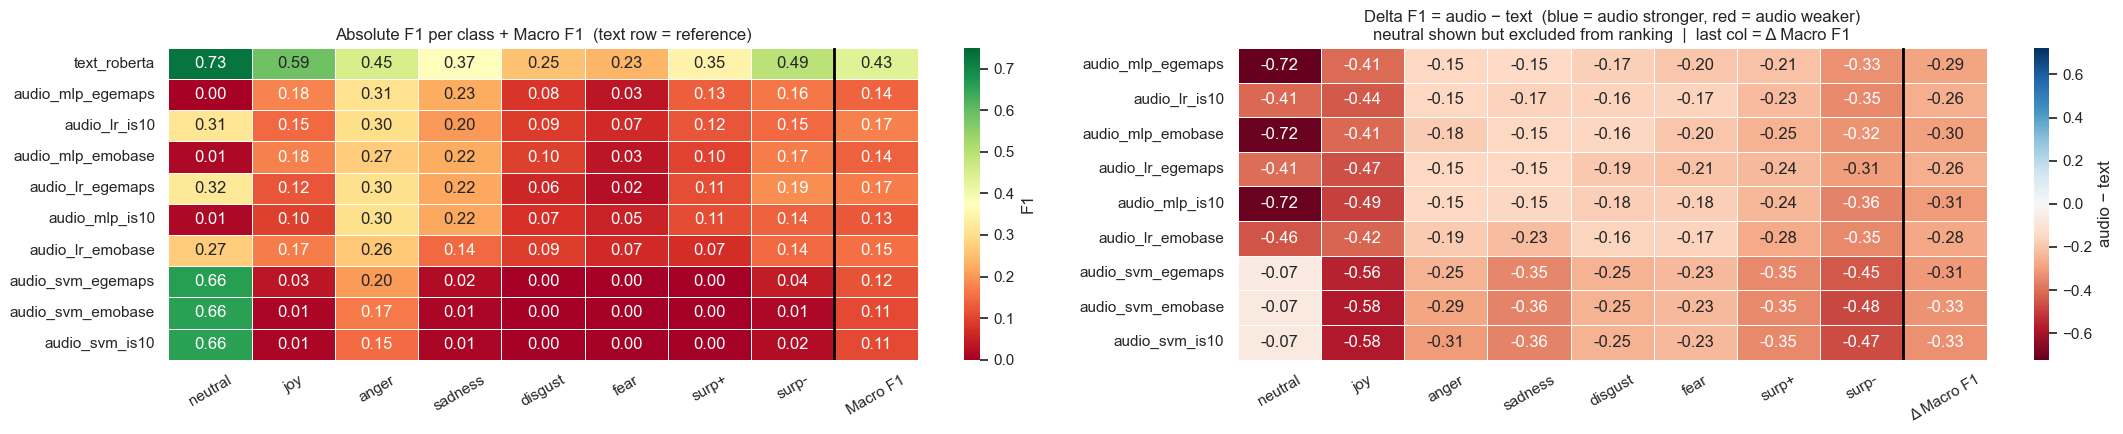

Ranking by complementarity score (neutral excluded):
Score = audio F1 weighted by (1 − text_F1) — classes where text struggles most count most.

  Model                                Comp score  Macro F1
  -----------------------------------  ----------  --------
  audio_mlp_egemaps                        0.1498    0.1405  ← selected
  audio_lr_is10                            0.1460    0.1732
  audio_mlp_emobase                        0.1432    0.1353
  audio_lr_egemaps                         0.1379    0.1690
  audio_mlp_is10                           0.1363    0.1256
  audio_lr_emobase                         0.1283    0.1534
  audio_svm_egemaps                        0.0373    0.1201
  audio_svm_emobase                        0.0251    0.1067
  audio_svm_is10                           0.0239    0.1058

Selected : audio_mlp_egemaps
Score    : 0.1498


In [8]:
_ALL_AUDIO_TAGS = [
    audio_tag('lr',  'is10'),
    audio_tag('lr',  'egemaps'),
    audio_tag('lr',  'emobase'),
    audio_tag('svm', 'egemaps'),
    audio_tag('svm', 'emobase'),
    audio_tag('svm', 'is10'),
    audio_tag('mlp', 'egemaps'),
    audio_tag('mlp', 'emobase'),
    audio_tag('mlp', 'is10'),
]
_SHORT = {
    'neutral': 'neutral', 'joy': 'joy', 'anger': 'anger',
    'sadness': 'sadness', 'disgust': 'disgust', 'fear': 'fear',
    'surprise_positive': 'surp+', 'surprise_negative': 'surp-',
}
_SCORE_CLASSES = [c for c in EMOTION_LABELS if c != 'neutral']

_text_p = get_metrics_path('text_roberta')
if not _text_p.exists():
    print('text_roberta.json not found — run section 8 first, then re-run this cell.')
    print(f'BEST_AUDIO_TAG stays: {BEST_AUDIO_TAG}  (set in cc01)')
else:
    _tm          = json.loads(_text_p.read_text())
    _tf1         = {c: _tm['per_class'][c]['f1'] for c in EMOTION_LABELS}
    _text_macro  = _tm['macro_f1']
    _tweak       = np.array([1 - _tf1[c] for c in _SCORE_CLASSES])

    # ── Collect per-class F1 for every audio model ────────────────────────────
    _rows = []
    for tag in _ALL_AUDIO_TAGS:
        p = get_metrics_path(tag)
        if not p.exists():
            continue
        m   = json.loads(p.read_text())
        row = {'model': tag, 'macro_f1_all': m['macro_f1']}
        for c in EMOTION_LABELS:
            row[c] = m['per_class'][c]['f1']
        af1 = np.array([m['per_class'][c]['f1'] for c in _SCORE_CLASSES])
        row['comp_score'] = float((af1 * _tweak).sum() / _tweak.sum())
        _rows.append(row)

    _df = (pd.DataFrame(_rows)
             .set_index('model')
             .sort_values('comp_score', ascending=False))
    BEST_AUDIO_TAG = _df.index[0]

    # ── Build DataFrames — per-class columns + Macro F1 summary column ────────
    _abs_rows, _delta_rows = [], []
    for tag, row in _df.iterrows():
        _abs_rows.append({
            'model': tag,
            **{_SHORT[c]: row[c] for c in EMOTION_LABELS},
            'Macro F1': row['macro_f1_all'],
        })
        _delta_rows.append({
            'model': tag,
            **{_SHORT[c]: row[c] - _tf1[c] for c in EMOTION_LABELS},
            'Δ Macro F1': row['macro_f1_all'] - _text_macro,
        })

    _text_row = {
        'model': 'text_roberta',
        **{_SHORT[c]: _tf1[c] for c in EMOTION_LABELS},
        'Macro F1': _text_macro,
    }
    _abs_df   = pd.DataFrame([_text_row] + _abs_rows).set_index('model')
    _delta_df = pd.DataFrame(_delta_rows).set_index('model')

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(22, 4.5))

    # Left: absolute F1 — per-class + Macro F1 column
    sns.heatmap(
        _abs_df, annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=0.0, vmax=0.75, linewidths=0.4, ax=axes[0],
        cbar_kws={'label': 'F1'},
    )
    # Vertical line separating per-class from macro summary
    axes[0].axvline(x=len(EMOTION_LABELS), color='black', linewidth=2)
    axes[0].set_title('Absolute F1 per class + Macro F1  (text row = reference)')
    axes[0].set_xlabel(''); axes[0].set_ylabel('')
    axes[0].tick_params(axis='x', rotation=30)

    # Right: delta F1 = audio − text — per-class + Δ Macro F1
    _vmax = max(abs(_delta_df.values.min()), abs(_delta_df.values.max()))
    sns.heatmap(
        _delta_df, annot=True, fmt='+.2f', cmap='RdBu',
        vmin=-_vmax, vmax=_vmax, center=0,
        linewidths=0.4, ax=axes[1],
        cbar_kws={'label': 'audio − text'},
    )
    axes[1].axvline(x=len(EMOTION_LABELS), color='black', linewidth=2)
    axes[1].set_title(
        'Delta F1 = audio − text  (blue = audio stronger, red = audio weaker)\n'
        'neutral shown but excluded from ranking  |  last col = Δ Macro F1'
    )
    axes[1].set_xlabel(''); axes[1].set_ylabel('')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'plots' / 'audio_text_overlap.png', dpi=150)
    plt.show()

    # ── Complementarity ranking ───────────────────────────────────────────────
    print('Ranking by complementarity score (neutral excluded):')
    print('Score = audio F1 weighted by (1 − text_F1) — classes where text struggles most count most.\n')
    print(f'  {"Model":35s}  {"Comp score":>10s}  {"Macro F1":>8s}')
    print(f'  {"-"*35}  {"-"*10}  {"-"*8}')
    for tag, row in _df.iterrows():
        marker = '  ← selected' if tag == BEST_AUDIO_TAG else ''
        print(f'  {tag:35s}  {row["comp_score"]:10.4f}  {row["macro_f1_all"]:8.4f}{marker}')

    print(f'\nSelected : {BEST_AUDIO_TAG}')
    print(f'Score    : {_df.loc[BEST_AUDIO_TAG, "comp_score"]:.4f}')

## 5 · Late Fusion — All Audio Models × RoBERTa

Simplest fusion: **`fused = (audio_softmax + text_softmax) / 2`**, then argmax.

No training, no hyperparameters — just an inference-time average. Run for every audio model whose softmax predictions are saved in `outputs/predictions/`.

This section computes 9 fused variants and saves each as `mm_late_<audio_short>` so they show up in the final comparison table.

In [9]:
# Compute late fusion for every available audio model.

_text_softmax = np.load(get_prediction_path('text_roberta', 'test'))
_y_test       = test_df['label_idx'].values.astype(int)
_text_mf1     = f1_score(_y_test, _text_softmax.argmax(1), average='macro',    zero_division=0)
_text_wf1     = f1_score(_y_test, _text_softmax.argmax(1), average='weighted', zero_division=0)

print(f'Text only  mF1={_text_mf1:.4f}  wF1={_text_wf1:.4f}\n')

# Discover audio models via their saved softmax predictions
_audio_pred_paths = sorted(PREDICTIONS_DIR.glob('audio_*_softmax_test.npy'))
_audio_tags = []
for _p in _audio_pred_paths:
    _t = _p.stem.replace('_softmax_test', '')
    _parts = _t.replace('audio_', '').split('_')
    if len(_parts) < 2 or not get_metrics_path(_t).exists():
        continue
    _audio_tags.append(_t)
print(f'Found {len(_audio_tags)} audio models:')
for t in _audio_tags:
    print(f'  • {t}')

# Compute fusion & save metrics for each combination
_late_rows = []
for _atag in _audio_tags:
    _audio_sf = np.load(get_prediction_path(_atag, 'test'))
    if _audio_sf.shape != _text_softmax.shape:
        print(f'  [skip] {_atag} — shape mismatch')
        continue

    _fused      = (_text_softmax + _audio_sf) / 2
    _fused_pred = _fused.argmax(1)
    _fused_tag  = f'{LATE_PREFIX}_{_atag.replace("audio_", "")}'

    evaluate_and_save(_y_test, _fused_pred, model_name=_fused_tag)
    np.save(get_prediction_path(_fused_tag, 'test'), _fused.astype(np.float32))

    _m = json.loads(get_metrics_path(_fused_tag).read_text())
    _audio_m = json.loads(get_metrics_path(_atag).read_text()) if get_metrics_path(_atag).exists() else {}
    _late_rows.append({
        'audio_tag':  _atag,
        'audio_mf1':  _audio_m.get('macro_f1', 0),
        'audio_wf1':  _audio_m.get('weighted_f1', 0),
        'fused_tag':  _fused_tag,
        'fused_mf1':  _m['macro_f1'],
        'fused_wf1':  _m['weighted_f1'],
        'delta_mf1':  _m['macro_f1']    - _text_mf1,
        'delta_wf1':  _m['weighted_f1'] - _text_wf1,
        **{COL_NAMES[c]: _m['per_class'][c]['f1'] for c in EMOTION_LABELS},
    })

df_late = pd.DataFrame(_late_rows).sort_values('fused_mf1', ascending=False).reset_index(drop=True)
print(f'\n{len(df_late)} late-fusion combinations computed.')
df_late[['audio_tag', 'audio_mf1', 'fused_mf1', 'fused_wf1', 'delta_mf1', 'delta_wf1']]

Text only  mF1=0.4338  wF1=0.5879

Found 14 audio models:
  • audio_lr_egemaps
  • audio_lr_emobase
  • audio_lr_is10_ctx
  • audio_lr_is10
  • audio_lr
  • audio_mlp_egemaps_ctx
  • audio_mlp_egemaps
  • audio_mlp_emobase_ctx
  • audio_mlp_emobase
  • audio_mlp_is10_ctx
  • audio_mlp_is10
  • audio_svm_egemaps
  • audio_svm_emobase
  • audio_svm_is10

Model: mm_late_lr_egemaps
  Weighted F1 : 0.5915
  Macro F1    : 0.4389
  Accuracy    : 0.5747
                   precision    recall  f1-score   support

          neutral       0.82      0.65      0.73      1256
              joy       0.55      0.63      0.59       402
            anger       0.50      0.43      0.46       345
          sadness       0.39      0.38      0.38       208
          disgust       0.21      0.34      0.26        68
             fear       0.17      0.38      0.24        50
surprise_positive       0.29      0.46      0.36       119
surprise_negative       0.41      0.63      0.50       162

         accuracy

,audio_tag,audio_mf1,fused_mf1,fused_wf1,delta_mf1,delta_wf1
0,audio_svm_egemaps,0.1201,0.4535,0.6178,0.019712,0.029884
1,audio_svm_emobase,0.1067,0.4525,0.6184,0.018712,0.030484
2,audio_svm_is10,0.1058,0.4521,0.6158,0.018312,0.027884
3,audio_lr_is10,0.1732,0.4432,0.5911,0.009412,0.003184
4,audio_mlp_is10_ctx,0.1274,0.4419,0.5872,0.008112,-0.000716
5,audio_mlp_emobase_ctx,0.1224,0.4399,0.5872,0.006112,-0.000716
6,audio_mlp_emobase,0.1353,0.4396,0.5891,0.005812,0.001184
7,audio_lr_egemaps,0.1690,0.4389,0.5915,0.005112,0.003584
8,audio_mlp_is10,0.1256,0.4387,0.5888,0.004912,0.000884
9,audio_lr,0.0000,0.4378,0.5916,0.004012,0.003684


### 5.1 · Macro F1 ranking and delta from text

Left: absolute fused macro F1 per audio model, with the text-only baseline marked.
Right: delta from text-only (orange = fusion improves over text, blue = fusion hurts).

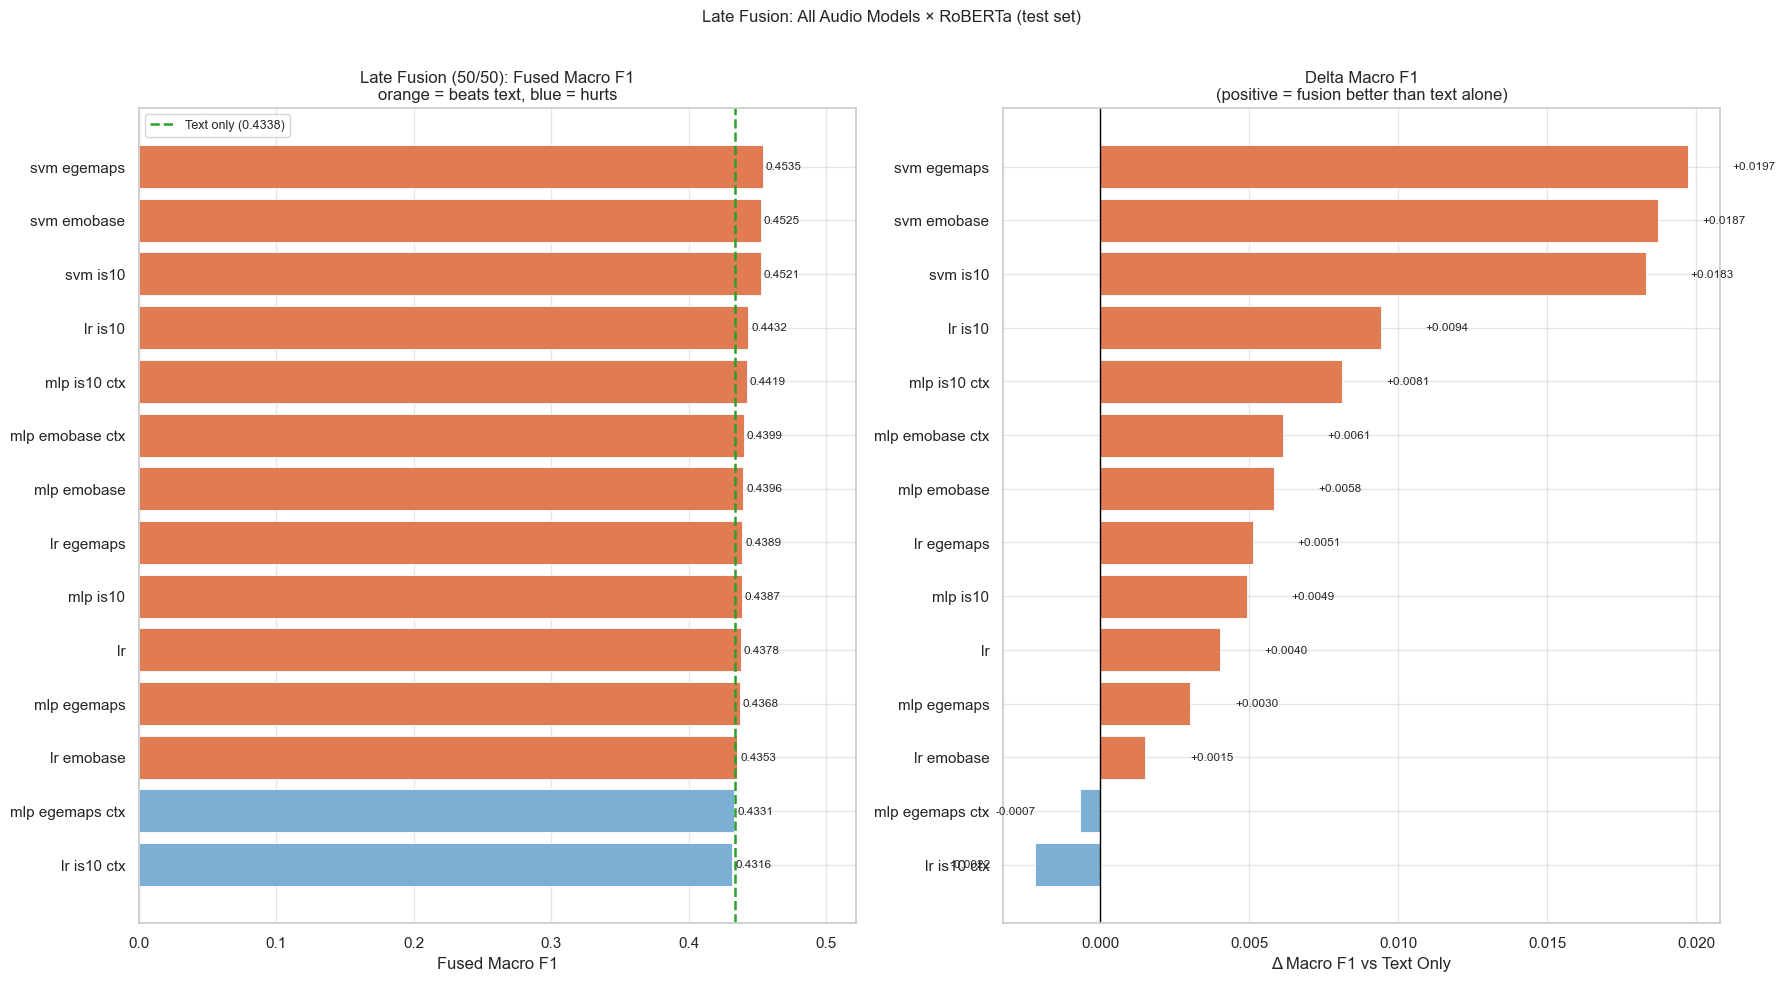

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 0.55 * len(df_late) + 2))

_labels  = df_late['audio_tag'].str.replace('audio_', '').str.replace('_', ' ')
_colors  = ['#e07b54' if d > 0 else '#7bafd4' for d in df_late['delta_mf1']]

_bars = axes[0].barh(_labels, df_late['fused_mf1'], color=_colors,
                     edgecolor='white', linewidth=0.6)
axes[0].axvline(_text_mf1, color='#2ca02c', linewidth=1.8, linestyle='--',
                label=f'Text only ({_text_mf1:.4f})')
for bar, val in zip(_bars, df_late['fused_mf1']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=8.5)
axes[0].set_xlabel('Fused Macro F1')
axes[0].set_title('Late Fusion (50/50): Fused Macro F1\norange = beats text, blue = hurts')
axes[0].set_xlim(0, df_late['fused_mf1'].max() * 1.15)
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)

_dbars = axes[1].barh(_labels, df_late['delta_mf1'], color=_colors,
                      edgecolor='white', linewidth=0.6)
axes[1].axvline(0, color='black', linewidth=1.0)
for bar, val in zip(_dbars, df_late['delta_mf1']):
    axes[1].text(
        bar.get_width() + (0.0015 if val >= 0 else -0.0015),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.4f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=8.5,
    )
axes[1].set_xlabel('Δ Macro F1 vs Text Only')
axes[1].set_title('Delta Macro F1\n(positive = fusion better than text alone)')
axes[1].invert_yaxis()

plt.suptitle('Late Fusion: All Audio Models × RoBERTa (test set)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'late_fusion_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 · Per-class delta heatmap

For each fusion variant, the change in per-class F1 relative to text-only. **Blue = audio helped, red = audio hurt** that emotion class. This makes it immediately clear whether a fusion gain is broad (multiple classes improve) or driven by a single class (typically `neutral` for the SVM models).

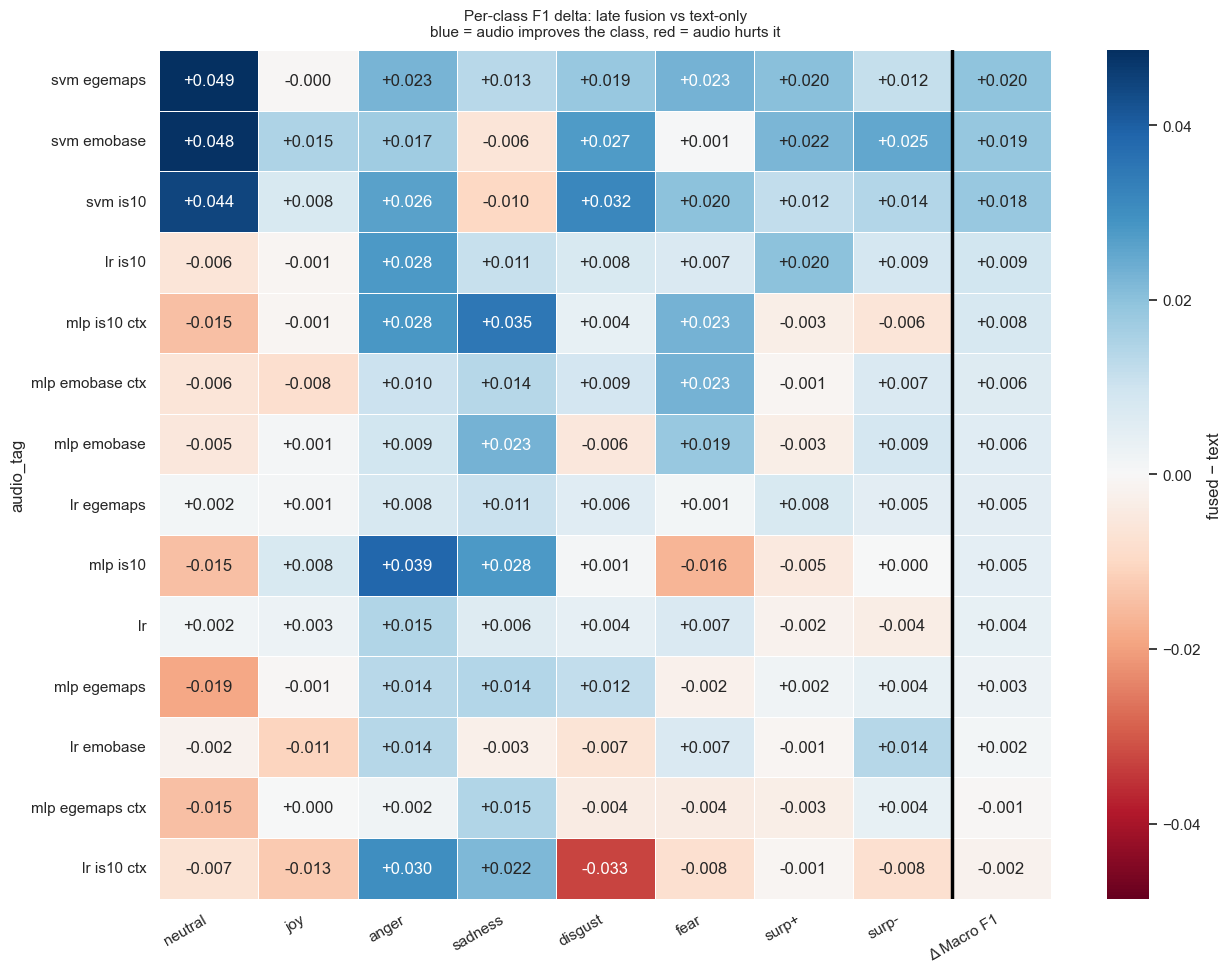

In [11]:
# Per-class delta heatmap: each row is one fusion variant, each cell is fused_F1 − text_F1.
_text_per = {COL_NAMES[c]: json.loads(get_metrics_path('text_roberta').read_text())['per_class'][c]['f1']
             for c in EMOTION_LABELS}

_class_cols = list(COL_NAMES.values())

_delta_rows = []
for _, row in df_late.iterrows():
    _delta_rows.append({
        **{col: row[col] - _text_per[col] for col in _class_cols},
        'Δ Macro F1': row['delta_mf1'],
    })
_df_late_delta = pd.DataFrame(
    _delta_rows,
    index=df_late['audio_tag'].str.replace('audio_', '').str.replace('_', ' '),
)

_vmax = max(abs(_df_late_delta.values.min()), abs(_df_late_delta.values.max()))

fig, ax = plt.subplots(figsize=(13, 0.6 * len(_df_late_delta) + 1.5))
sns.heatmap(_df_late_delta, annot=True, fmt='+.3f', cmap='RdBu',
            vmin=-_vmax, vmax=_vmax, center=0, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'fused − text'})
ax.axvline(len(_class_cols), color='black', linewidth=2.5)
ax.set_title('Per-class F1 delta: late fusion vs text-only\nblue = audio improves the class, red = audio hurts it',
             fontsize=11, pad=10)
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'late_fusion_perclass_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Feature Fusion MLP — All Audio Models × RoBERTa

The audio model's 8-d softmax is concatenated with RoBERTa's 768-d CLS embedding (StandardScaler-normalized) and passed through a 2-layer MLP with BatchNorm + Dropout, trained with FocalLoss + class weights.

For each of the 9 audio models we run a **mini-Optuna search** (10 trials, 20 epochs, patience 3) followed by a final training run (60 epochs, patience 7). Total compute on CPU: roughly 30–60 minutes for the full sweep.

The architecture is identical across runs — only the audio softmax source changes. This isolates the contribution of each audio model when given the same fusion treatment.

In [12]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, targets):
        log_p = F.log_softmax(logits, dim=-1)
        w     = self.weight.to(logits.device) if self.weight is not None else None
        ce    = F.nll_loss(log_p, targets, weight=w, reduction='none')
        p_t   = torch.exp(-ce)
        return ((1 - p_t) ** self.gamma * ce).mean()


class FusionMLP(nn.Module):
    def __init__(self, input_dim, hidden, dropout):
        super().__init__()
        layers, dim = [], input_dim
        for h in hidden:
            layers += [nn.Linear(dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            dim = h
        layers.append(nn.Linear(dim, NUM_CLASSES))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

### 6.1 · Helpers — load audio softmax for any audio model

Self-contained helper that reproduces the audio softmax for a given trained model (LR, SVM, or MLP) on any split, using the model's own scaler and feature set.

In [13]:
# Helper: compute audio softmax for any audio_<model>_<feature_set> tag.
# Returns (N, NUM_CLASSES) class-probability array.

from audio.mlp.model import AudioMLP

_ID_COLS = {'dialogue_id', 'utterance_id', 'label_idx'}

def _scaled_features(audio_tag, split_name, split_df):
    """Load and scale the audio features for a given model+split."""
    # parse audio_<modelkey>_<featureset>[_ctx]
    parts        = audio_tag.replace('audio_', '').split('_')
    use_context  = parts[-1] == 'ctx'
    feature_set  = parts[1] if use_context else parts[-1]
    # NB: ctx variants pre-pend previous-utterance features — handled by load_feature_dataframe
    if use_context:
        from audio.dataset import load_feature_dataframe
        df = load_feature_dataframe(split_name, feature_set, use_context=True)
        # Align to split_df order
        merged = split_df[['dialogue_id', 'utterance_id']].merge(
            df, on=['dialogue_id', 'utterance_id'], how='left',
        )
        feat_cols = [c for c in df.columns if c not in _ID_COLS]
        X_raw = merged[feat_cols].fillna(0.0).values.astype(np.float32)
    elif feature_set == AUDIO_FEATURE_SET:
        feat_cols = [c for c in split_df.columns if c not in _ID_COLS and c != 'text_with_context']
        X_raw = split_df[feat_cols].values.astype(np.float32)
    else:
        feat_df   = pd.read_parquet(FEATURES_DIR / f'{split_name}_{feature_set}.parquet').dropna()
        feat_cols = [c for c in feat_df.columns if c not in _ID_COLS]
        aligned   = split_df[['dialogue_id', 'utterance_id']].merge(
            feat_df[['dialogue_id', 'utterance_id'] + feat_cols],
            on=['dialogue_id', 'utterance_id'], how='left',
        )
        X_raw = aligned[feat_cols].fillna(0.0).values.astype(np.float32)

    with open(get_scaler_path(audio_tag), 'rb') as f:
        scaler = pickle.load(f)
    return scaler.transform(X_raw)


def _reorder_proba(proba, classes):
    out = np.zeros((len(proba), NUM_CLASSES), dtype=np.float32)
    for col_i, cls_i in enumerate(classes):
        out[:, cls_i] = proba[:, col_i]
    return out


def get_audio_softmax(audio_tag, split_name, split_df):
    """Return 8-dim class-probability vector for any saved audio model."""
    model_type = audio_tag.split('_')[1]        # lr | svm | mlp
    X_sc       = _scaled_features(audio_tag, split_name, split_df)

    if model_type in ('lr', 'svm'):
        with open(get_model_path(audio_tag), 'rb') as f:
            clf = pickle.load(f)
        return _reorder_proba(clf.predict_proba(X_sc), clf.classes_)
    else:  # mlp
        hp  = json.loads(get_hparams_path(audio_tag).read_text())
        net = AudioMLP(X_sc.shape[1], [hp['hidden_1'], hp['hidden_2']], dropout=0.0)
        net.load_state_dict(torch.load(get_model_path(audio_tag), map_location='cpu'))
        net.eval()
        with torch.no_grad():
            return F.softmax(net(torch.tensor(X_sc)), dim=1).numpy().astype(np.float32)


# Fit CLS scaler once on train, reuse across all combinations.
cls_train = np.load(FEATURES_DIR / f'roberta_cls_trial{BEST_TRIAL}' / 'train.npy')
cls_dev   = np.load(FEATURES_DIR / f'roberta_cls_trial{BEST_TRIAL}' / 'dev.npy')
cls_test  = np.load(FEATURES_DIR / f'roberta_cls_trial{BEST_TRIAL}' / 'test.npy')

cls_scaler   = StandardScaler()
cls_train_sc = cls_scaler.fit_transform(cls_train)
cls_dev_sc   = cls_scaler.transform(cls_dev)
cls_test_sc  = cls_scaler.transform(cls_test)

y_train = train_df['label_idx'].values.astype(int)
y_dev   = dev_df['label_idx'].values.astype(int)
y_test  = test_df['label_idx'].values.astype(int)
TEXT_DIM  = cls_train.shape[1]
AUDIO_DIM = NUM_CLASSES
INPUT_DIM = TEXT_DIM + AUDIO_DIM
print(f'Inputs: audio softmax {AUDIO_DIM}d + CLS {TEXT_DIM}d = {INPUT_DIM}d')
print(f'Sizes : train {len(y_train)}, dev {len(y_dev)}, test {len(y_test)}')

Inputs: audio softmax 8d + CLS 768d = 776d
Sizes : train 9982, dev 1106, test 2610


### 6.2 · Mini-Optuna sweep — every audio model

For each audio model:
1. Compute audio softmax (train / dev / test) using its saved checkpoint.
2. Concatenate with scaled CLS embeddings.
3. Run mini-Optuna (10 trials, 20 epochs, patience 3) on dev macro-F1.
4. Final training (60 epochs, patience 7) with best hparams.
5. Save metrics + softmax predictions as `mm_ff_<audio_short>`.

Skips combinations whose metrics file already exists — re-running is incremental.

In [15]:
# Mini-Optuna feature fusion sweep across all audio models.

MINI_BATCH_SIZE     = 64
MINI_N_TRIALS       = 10
MINI_SEARCH_EPOCHS  = 20
MINI_SEARCH_PATIENCE = 3
MINI_FINAL_EPOCHS   = 60
MINI_FINAL_PATIENCE = 7


def _ff_make_loader(X, y, shuffle):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=MINI_BATCH_SIZE, shuffle=shuffle, drop_last=shuffle)


def _ff_class_weights(y):
    w = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y)
    return torch.tensor(w, dtype=torch.float32)


def _ff_run_epoch(model, loader, crit, opt=None):
    training = opt is not None
    model.train() if training else model.eval()
    preds, labels = [], []
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = crit(logits, y)
            if training:
                opt.zero_grad(); loss.backward(); opt.step()
            preds.extend(logits.argmax(1).cpu().tolist())
            labels.extend(y.cpu().tolist())
    return f1_score(labels, preds, average='macro', zero_division=0)


def _ff_train(X_tr, y_tr, X_dv, y_dv, hp, max_epochs, patience, checkpoint=None):
    cw    = _ff_class_weights(y_tr).to(DEVICE)
    model = FusionMLP(INPUT_DIM, [hp['hidden_1'], hp['hidden_2']], hp['dropout']).to(DEVICE)
    crit  = FocalLoss(weight=cw, gamma=hp['focal_gamma'])
    opt   = torch.optim.Adam(model.parameters(), lr=hp['lr'])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=5)
    tr_ld = _ff_make_loader(X_tr, y_tr, True)
    dv_ld = _ff_make_loader(X_dv, y_dv, False)
    best, no_impr = 0.0, 0
    for _ in range(max_epochs):
        _ff_run_epoch(model, tr_ld, crit, opt)
        dv = _ff_run_epoch(model, dv_ld, crit)
        sched.step(dv)
        if dv > best:
            best, no_impr = dv, 0
            if checkpoint:
                torch.save(model.state_dict(), checkpoint)
        else:
            no_impr += 1
            if no_impr >= patience:
                break
    return best


def _ff_objective(trial, X_tr, y_tr, X_dv, y_dv):
    hp = {
        'hidden_1':    trial.suggest_categorical('hidden_1',    [128, 256, 512]),
        'hidden_2':    trial.suggest_categorical('hidden_2',    [64, 128, 256]),
        'dropout':     trial.suggest_float('dropout',     0.2, 0.5),
        'lr':          trial.suggest_float('lr',          1e-4, 1e-2, log=True),
        'focal_gamma': trial.suggest_float('focal_gamma', 1.0, 3.0),
    }
    return _ff_train(X_tr, y_tr, X_dv, y_dv, hp,
                     MINI_SEARCH_EPOCHS, MINI_SEARCH_PATIENCE, checkpoint=None)


# ── Main sweep loop ───────────────────────────────────────────────────────────
_ff_rows = []
_audio_pred_paths = sorted(PREDICTIONS_DIR.glob('audio_*_softmax_test.npy'))
_audio_tags = []
for _p in _audio_pred_paths:
    _t = _p.stem.replace('_softmax_test', '')
    # Validate format: audio_<model>_<feature_set>[_ctx]
    _parts = _t.replace('audio_', '').split('_')
    if len(_parts) < 2:
        print(f'  [skip] {_t} — no feature set in name')
        continue
    if not get_metrics_path(_t).exists():
        print(f'  [skip] {_t} — no metrics file (orphan)')
        continue
    _audio_tags.append(_t)

for _idx, _atag in enumerate(_audio_tags, 1):
    _ff_tag = f'{FF_PREFIX}_{_atag.replace("audio_", "")}'
    print(f'\n══ [{_idx}/{len(_audio_tags)}] {_atag}  →  {_ff_tag} ══')

    if get_metrics_path(_ff_tag).exists():
        print(f'  already done — loading metrics')
        _m = json.loads(get_metrics_path(_ff_tag).read_text())
        _ff_rows.append({'audio_tag': _atag, 'ff_tag': _ff_tag, **_m})
        continue

    # Build features
    print('  building features...')
    audio_tr = get_audio_softmax(_atag, 'train', train_df)
    audio_dv = get_audio_softmax(_atag, 'dev',   dev_df)
    audio_te = get_audio_softmax(_atag, 'test',  test_df)

    X_tr = np.concatenate([audio_tr, cls_train_sc], axis=1)
    X_dv = np.concatenate([audio_dv, cls_dev_sc],   axis=1)
    X_te = np.concatenate([audio_te, cls_test_sc],  axis=1)

    # Mini-Optuna search
    print(f'  Optuna ({MINI_N_TRIALS} trials)...')
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(lambda t: _ff_objective(t, X_tr, y_train, X_dv, y_dev),
                   n_trials=MINI_N_TRIALS, n_jobs=1, show_progress_bar=False)
    best_hp = study.best_params
    print(f'  best dev mF1 = {study.best_value:.4f}  hp = {best_hp}')

    # Final training
    _ckpt = get_model_path(_ff_tag)
    print('  final training...')
    _ff_train(X_tr, y_train, X_dv, y_dev, best_hp,
              MINI_FINAL_EPOCHS, MINI_FINAL_PATIENCE, checkpoint=_ckpt)

    with open(get_hparams_path(_ff_tag), 'w') as f:
        json.dump({**best_hp, 'dev_mf1': round(study.best_value, 4)}, f, indent=2)

    # Test evaluation
    model = FusionMLP(INPUT_DIM, [best_hp['hidden_1'], best_hp['hidden_2']],
                      best_hp['dropout']).to(DEVICE)
    model.load_state_dict(torch.load(_ckpt, map_location=DEVICE))
    model.eval()

    te_ld = _ff_make_loader(X_te, y_test, shuffle=False)
    probs, preds, labels = [], [], []
    with torch.no_grad():
        for x, y in te_ld:
            logits = model(x.to(DEVICE))
            probs.append(F.softmax(logits, dim=1).cpu())
            preds.extend(logits.argmax(1).cpu().tolist())
            labels.extend(y.tolist())

    evaluate_and_save(np.array(labels), np.array(preds), model_name=_ff_tag)
    np.save(get_prediction_path(_ff_tag, 'test'),
            torch.cat(probs).numpy().astype(np.float32))

    _m = json.loads(get_metrics_path(_ff_tag).read_text())
    print(f'  TEST mF1={_m["macro_f1"]:.4f}  wF1={_m["weighted_f1"]:.4f}')
    _ff_rows.append({'audio_tag': _atag, 'ff_tag': _ff_tag, **_m})

print(f'\n══ sweep complete: {len(_ff_rows)} feature-fusion variants trained ══')


══ [1/13] audio_lr_egemaps  →  mm_ff_lr_egemaps ══
  already done — loading metrics

══ [2/13] audio_lr_emobase  →  mm_ff_lr_emobase ══
  already done — loading metrics

══ [3/13] audio_lr_is10_ctx  →  mm_ff_lr_is10_ctx ══
  already done — loading metrics

══ [4/13] audio_lr_is10  →  mm_ff_lr_is10 ══
  already done — loading metrics

══ [5/13] audio_mlp_egemaps_ctx  →  mm_ff_mlp_egemaps_ctx ══
  building features...
  Optuna (10 trials)...
  best dev mF1 = 0.4143  hp = {'hidden_1': 512, 'hidden_2': 128, 'dropout': 0.4960660809801552, 'lr': 0.0035033984911586884, 'focal_gamma': 1.3974313630683448}
  final training...

Model: mm_ff_mlp_egemaps_ctx
  Weighted F1 : 0.5362
  Macro F1    : 0.4116
  Accuracy    : 0.5042
                   precision    recall  f1-score   support

          neutral       0.86      0.49      0.62      1256
              joy       0.56      0.62      0.59       402
            anger       0.47      0.46      0.46       345
          sadness       0.31      0.42 

### 6.3 · Per-class delta heatmap + macro F1 ranking

Same diagnostics as section 5.2/5.1, but for the feature-fusion MLP variants.

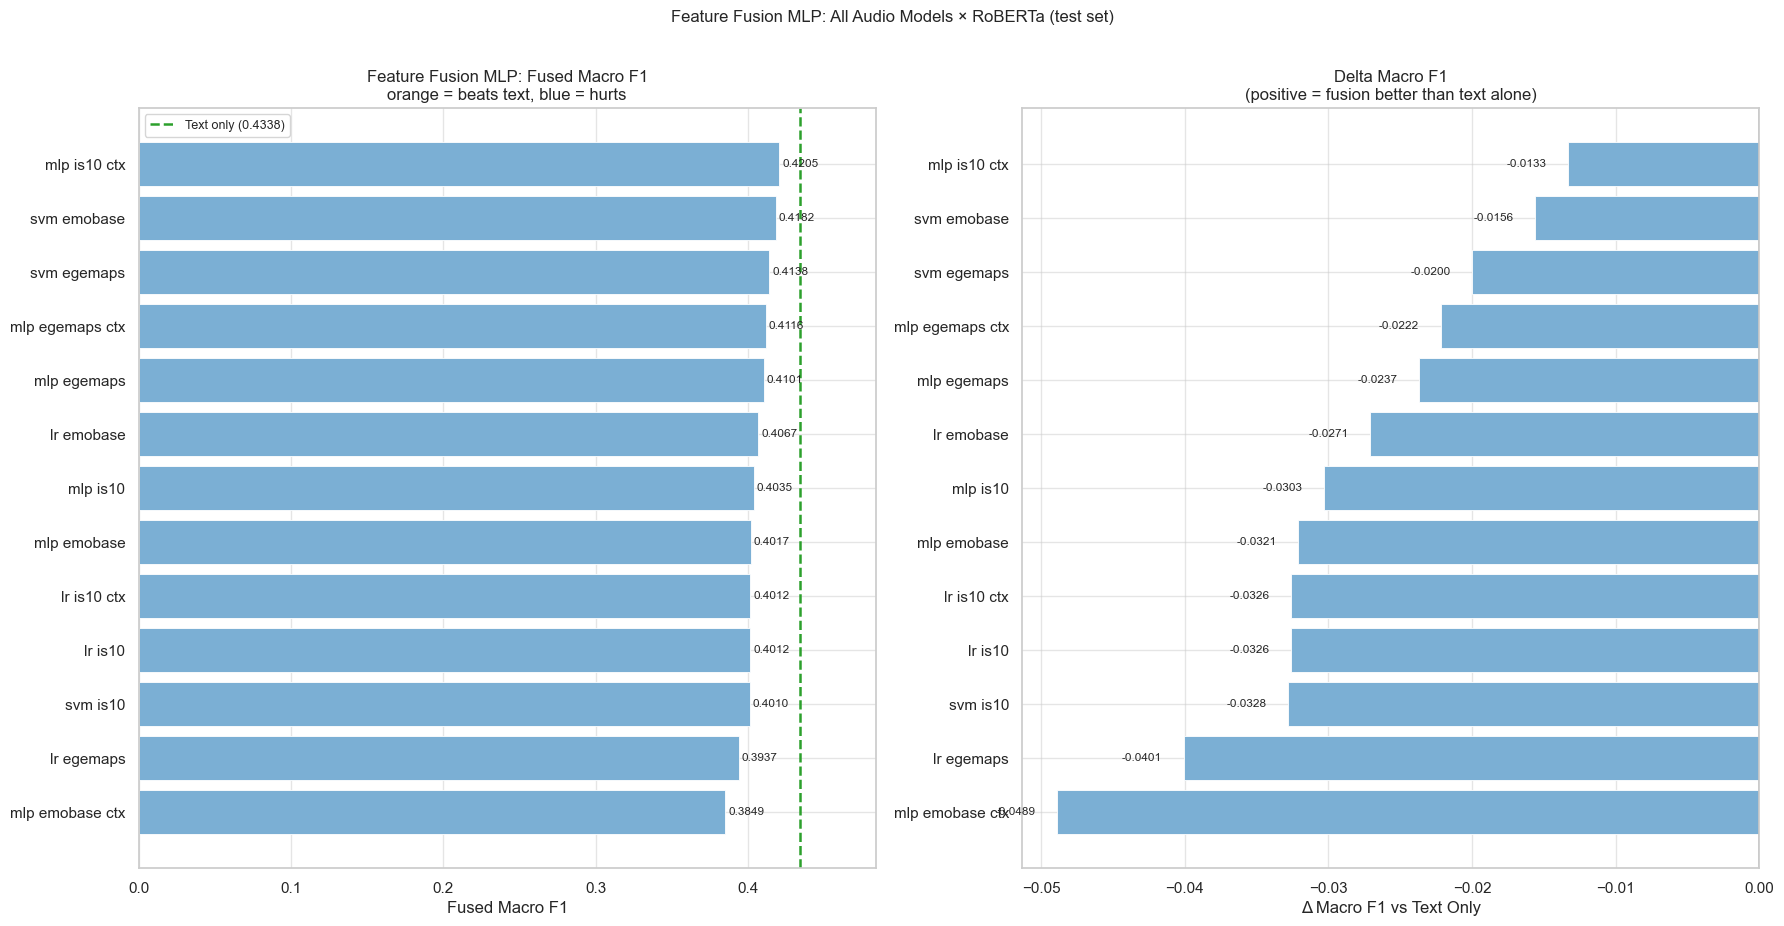

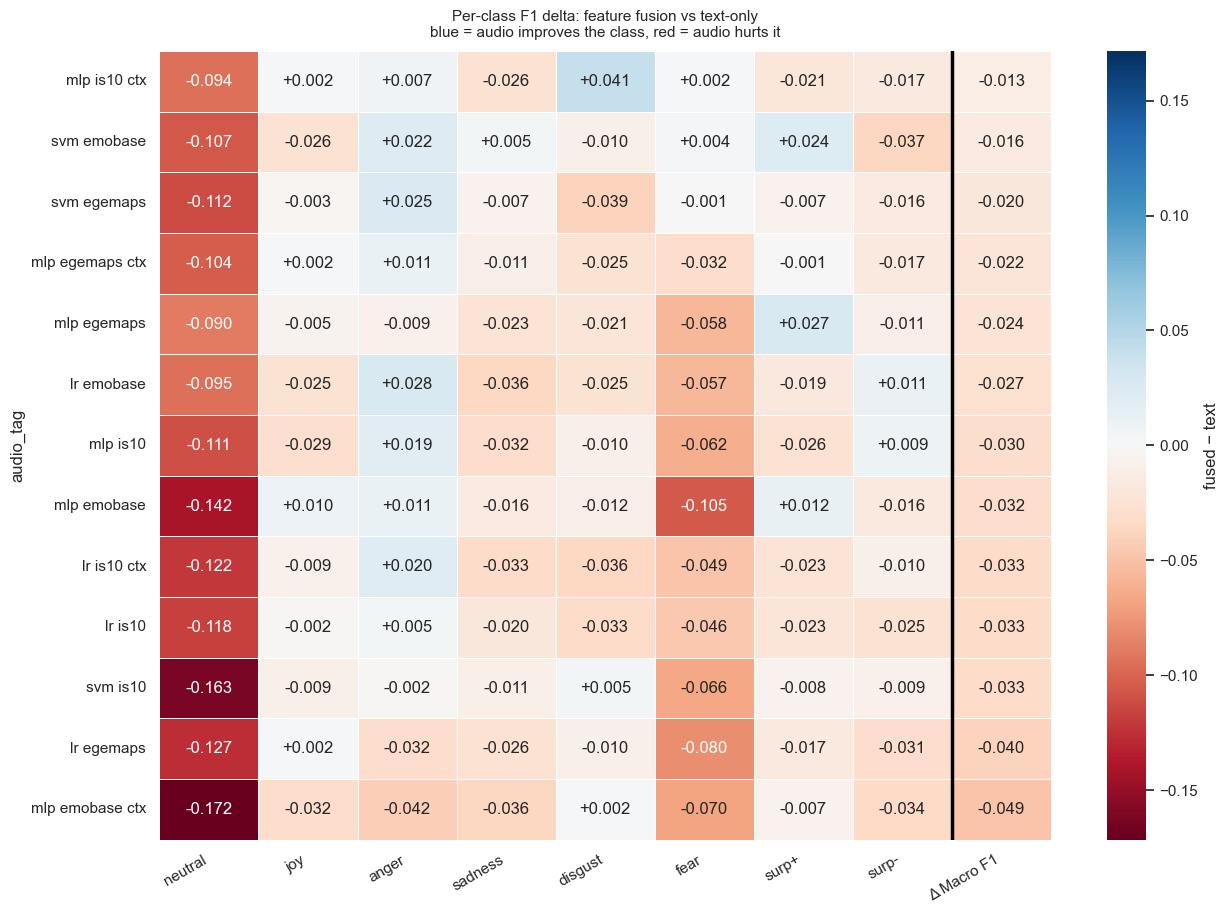

In [19]:
# Build feature-fusion comparison dataframe with per-class deltas.
_ff_data = []
for r in _ff_rows:
    _m = json.loads(get_metrics_path(r['ff_tag']).read_text())
    _ff_data.append({
        'audio_tag':  r['audio_tag'],
        'ff_tag':     r['ff_tag'],
        'fused_mf1':  _m['macro_f1'],
        'fused_wf1':  _m['weighted_f1'],
        'delta_mf1':  _m['macro_f1']    - _text_mf1,
        'delta_wf1':  _m['weighted_f1'] - _text_wf1,
        **{COL_NAMES[c]: _m['per_class'][c]['f1'] for c in EMOTION_LABELS},
    })

df_ff = pd.DataFrame(_ff_data).sort_values('fused_mf1', ascending=False).reset_index(drop=True)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 0.55 * len(df_ff) + 2))

_labels_ff = df_ff['audio_tag'].str.replace('audio_', '').str.replace('_', ' ')
_colors_ff = ['#e07b54' if d > 0 else '#7bafd4' for d in df_ff['delta_mf1']]

_bars = axes[0].barh(_labels_ff, df_ff['fused_mf1'], color=_colors_ff,
                     edgecolor='white', linewidth=0.6)
axes[0].axvline(_text_mf1, color='#2ca02c', linewidth=1.8, linestyle='--',
                label=f'Text only ({_text_mf1:.4f})')
for bar, val in zip(_bars, df_ff['fused_mf1']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=8.5)
axes[0].set_xlabel('Fused Macro F1')
axes[0].set_title('Feature Fusion MLP: Fused Macro F1\norange = beats text, blue = hurts')
axes[0].set_xlim(0, df_ff['fused_mf1'].max() * 1.15)
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)

_dbars = axes[1].barh(_labels_ff, df_ff['delta_mf1'], color=_colors_ff,
                      edgecolor='white', linewidth=0.6)
axes[1].axvline(0, color='black', linewidth=1.0)
for bar, val in zip(_dbars, df_ff['delta_mf1']):
    axes[1].text(
        bar.get_width() + (0.0015 if val >= 0 else -0.0015),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.4f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=8.5,
    )
axes[1].set_xlabel('Δ Macro F1 vs Text Only')
axes[1].set_title('Delta Macro F1\n(positive = fusion better than text alone)')
axes[1].invert_yaxis()

plt.suptitle('Feature Fusion MLP: All Audio Models × RoBERTa (test set)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'feature_fusion_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class delta heatmap ──────────────────────────────────────────────────
_class_cols = list(COL_NAMES.values())
_delta_rows_ff = []
for _, row in df_ff.iterrows():
    _delta_rows_ff.append({
        **{col: row[col] - _text_per[col] for col in _class_cols},
        'Δ Macro F1': row['delta_mf1'],
    })
_df_ff_delta = pd.DataFrame(_delta_rows_ff, index=_labels_ff)

_vmax = max(abs(_df_ff_delta.values.min()), abs(_df_ff_delta.values.max()))
fig, ax = plt.subplots(figsize=(13, 0.6 * len(_df_ff_delta) + 1.5))
sns.heatmap(_df_ff_delta, annot=True, fmt='+.3f', cmap='RdBu',
            vmin=-_vmax, vmax=_vmax, center=0, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'fused − text'})
ax.axvline(len(_class_cols), color='black', linewidth=2.5)
ax.set_title('Per-class F1 delta: feature fusion vs text-only\nblue = audio improves the class, red = audio hurts it',
             fontsize=11, pad=10)
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'feature_fusion_perclass_delta.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 · Late vs Feature Fusion — pairwise comparison

For each audio model, does the trained MLP actually beat the parameter-free 50/50 average? The answer is rarely obvious — feature fusion learns to weight the modalities adaptively, but it also has more capacity to overfit.

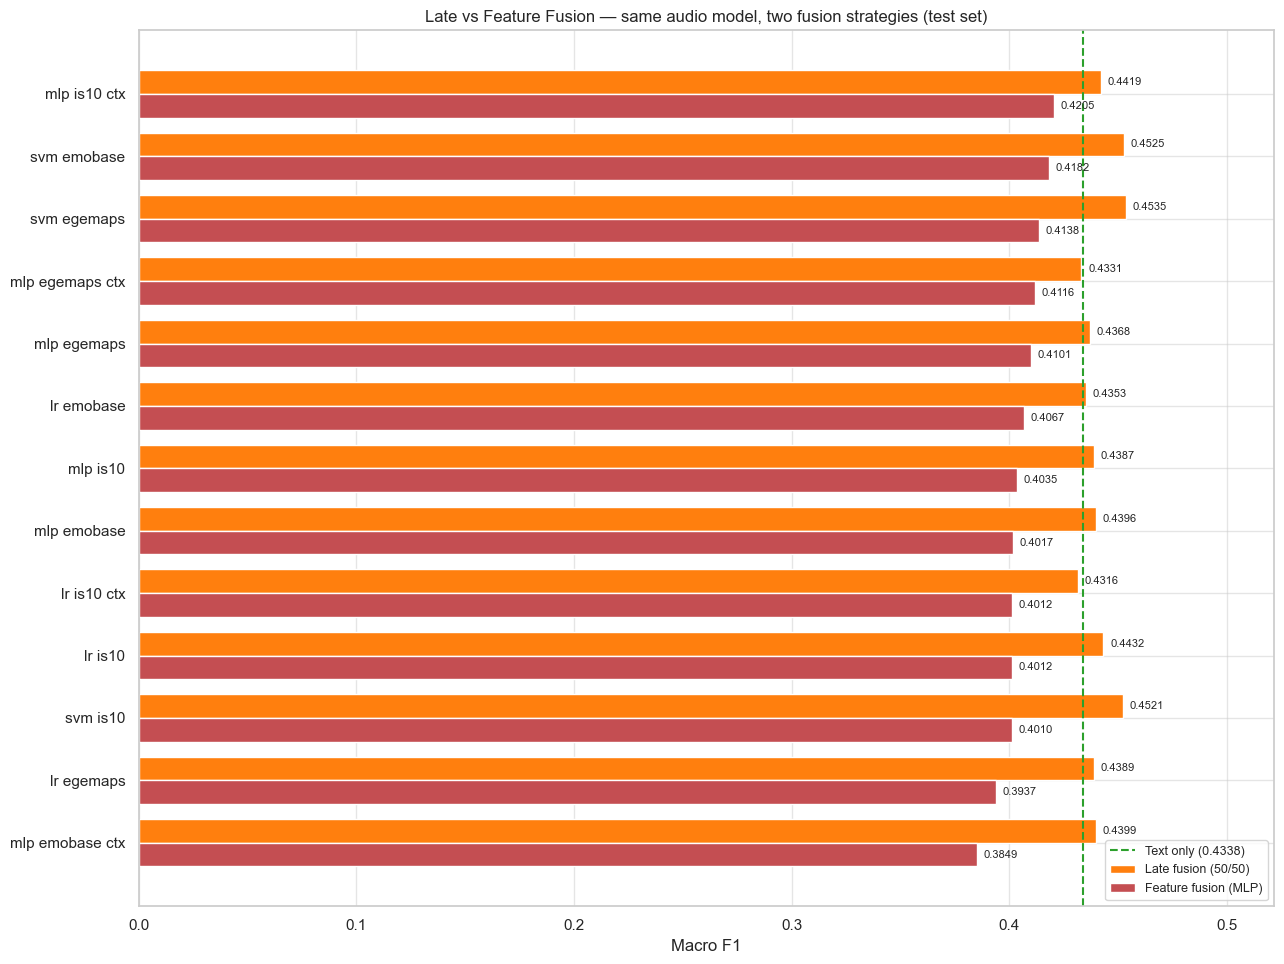


Difference (feature − late):
          audio  late_mf1  ff_mf1  mf1_diff  late_wf1  ff_wf1  wf1_diff
   mlp_is10_ctx    0.4419  0.4205   -0.0214    0.5872  0.5408   -0.0464
    svm_emobase    0.4525  0.4182   -0.0343    0.6184  0.5345   -0.0839
    svm_egemaps    0.4535  0.4138   -0.0397    0.6178  0.5339   -0.0839
mlp_egemaps_ctx    0.4331  0.4116   -0.0215    0.5822  0.5362   -0.0460
    mlp_egemaps    0.4368  0.4101   -0.0267    0.5824  0.5398   -0.0426
     lr_emobase    0.4353  0.4067   -0.0286    0.5877  0.5374   -0.0503
       mlp_is10    0.4387  0.4035   -0.0352    0.5888  0.5279   -0.0609
    mlp_emobase    0.4396  0.4017   -0.0379    0.5891  0.5187   -0.0704
    lr_is10_ctx    0.4316  0.4012   -0.0304    0.5867  0.5245   -0.0622
        lr_is10    0.4432  0.4012   -0.0420    0.5911  0.5257   -0.0654
       svm_is10    0.4521  0.4010   -0.0511    0.6158  0.5050   -0.1108
     lr_egemaps    0.4389  0.3937   -0.0452    0.5915  0.5165   -0.0750
mlp_emobase_ctx    0.4399  0.3849 

In [20]:
# Pair each late-fusion result with its feature-fusion counterpart.
_compare_rows = []
for _atag in _audio_tags:
    _late_tag = f'{LATE_PREFIX}_{_atag.replace("audio_", "")}'
    _ff_tag   = f'{FF_PREFIX}_{_atag.replace("audio_", "")}'
    _l = json.loads(get_metrics_path(_late_tag).read_text())  if get_metrics_path(_late_tag).exists() else None
    _f = json.loads(get_metrics_path(_ff_tag).read_text())    if get_metrics_path(_ff_tag).exists()   else None
    if not (_l and _f):
        continue
    _compare_rows.append({
        'audio':    _atag.replace('audio_', ''),
        'late_mf1': _l['macro_f1'],
        'late_wf1': _l['weighted_f1'],
        'ff_mf1':   _f['macro_f1'],
        'ff_wf1':   _f['weighted_f1'],
        'mf1_diff': _f['macro_f1']    - _l['macro_f1'],
        'wf1_diff': _f['weighted_f1'] - _l['weighted_f1'],
    })

df_compare = pd.DataFrame(_compare_rows).sort_values('ff_mf1', ascending=False).reset_index(drop=True)

# Grouped bar chart: late vs feature fusion mF1 per audio model
fig, ax = plt.subplots(figsize=(13, 0.6 * len(df_compare) + 2))
_x = np.arange(len(df_compare))
_w = 0.38
ax.barh(_x - _w/2, df_compare['late_mf1'], _w, label='Late fusion (50/50)',     color='#FF7F0E')
ax.barh(_x + _w/2, df_compare['ff_mf1'],   _w, label='Feature fusion (MLP)',    color='#C44E52')
ax.axvline(_text_mf1, color='#2ca02c', linewidth=1.5, linestyle='--', label=f'Text only ({_text_mf1:.4f})')

for i, r in df_compare.iterrows():
    ax.text(r['late_mf1'] + 0.003, i - _w/2, f'{r["late_mf1"]:.4f}', va='center', fontsize=8)
    ax.text(r['ff_mf1']   + 0.003, i + _w/2, f'{r["ff_mf1"]:.4f}',   va='center', fontsize=8)

ax.set_yticks(_x)
ax.set_yticklabels(df_compare['audio'].str.replace('_', ' '))
ax.set_xlabel('Macro F1')
ax.set_title('Late vs Feature Fusion — same audio model, two fusion strategies (test set)')
ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, max(df_compare['late_mf1'].max(), df_compare['ff_mf1'].max()) * 1.15)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'late_vs_feature_fusion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDifference (feature − late):')
print(df_compare[['audio', 'late_mf1', 'ff_mf1', 'mf1_diff', 'late_wf1', 'ff_wf1', 'wf1_diff']].to_string(index=False))

## 7 · Final Comparison — All Models, All Classes

Mega-heatmap with every variant trained: audio-only baselines, text-only, and every late + feature fusion combination.

Horizontal dividers separate audio / text / late-fusion / feature-fusion blocks; the thick vertical line separates per-class F1 from the macro/weighted F1 summary columns.

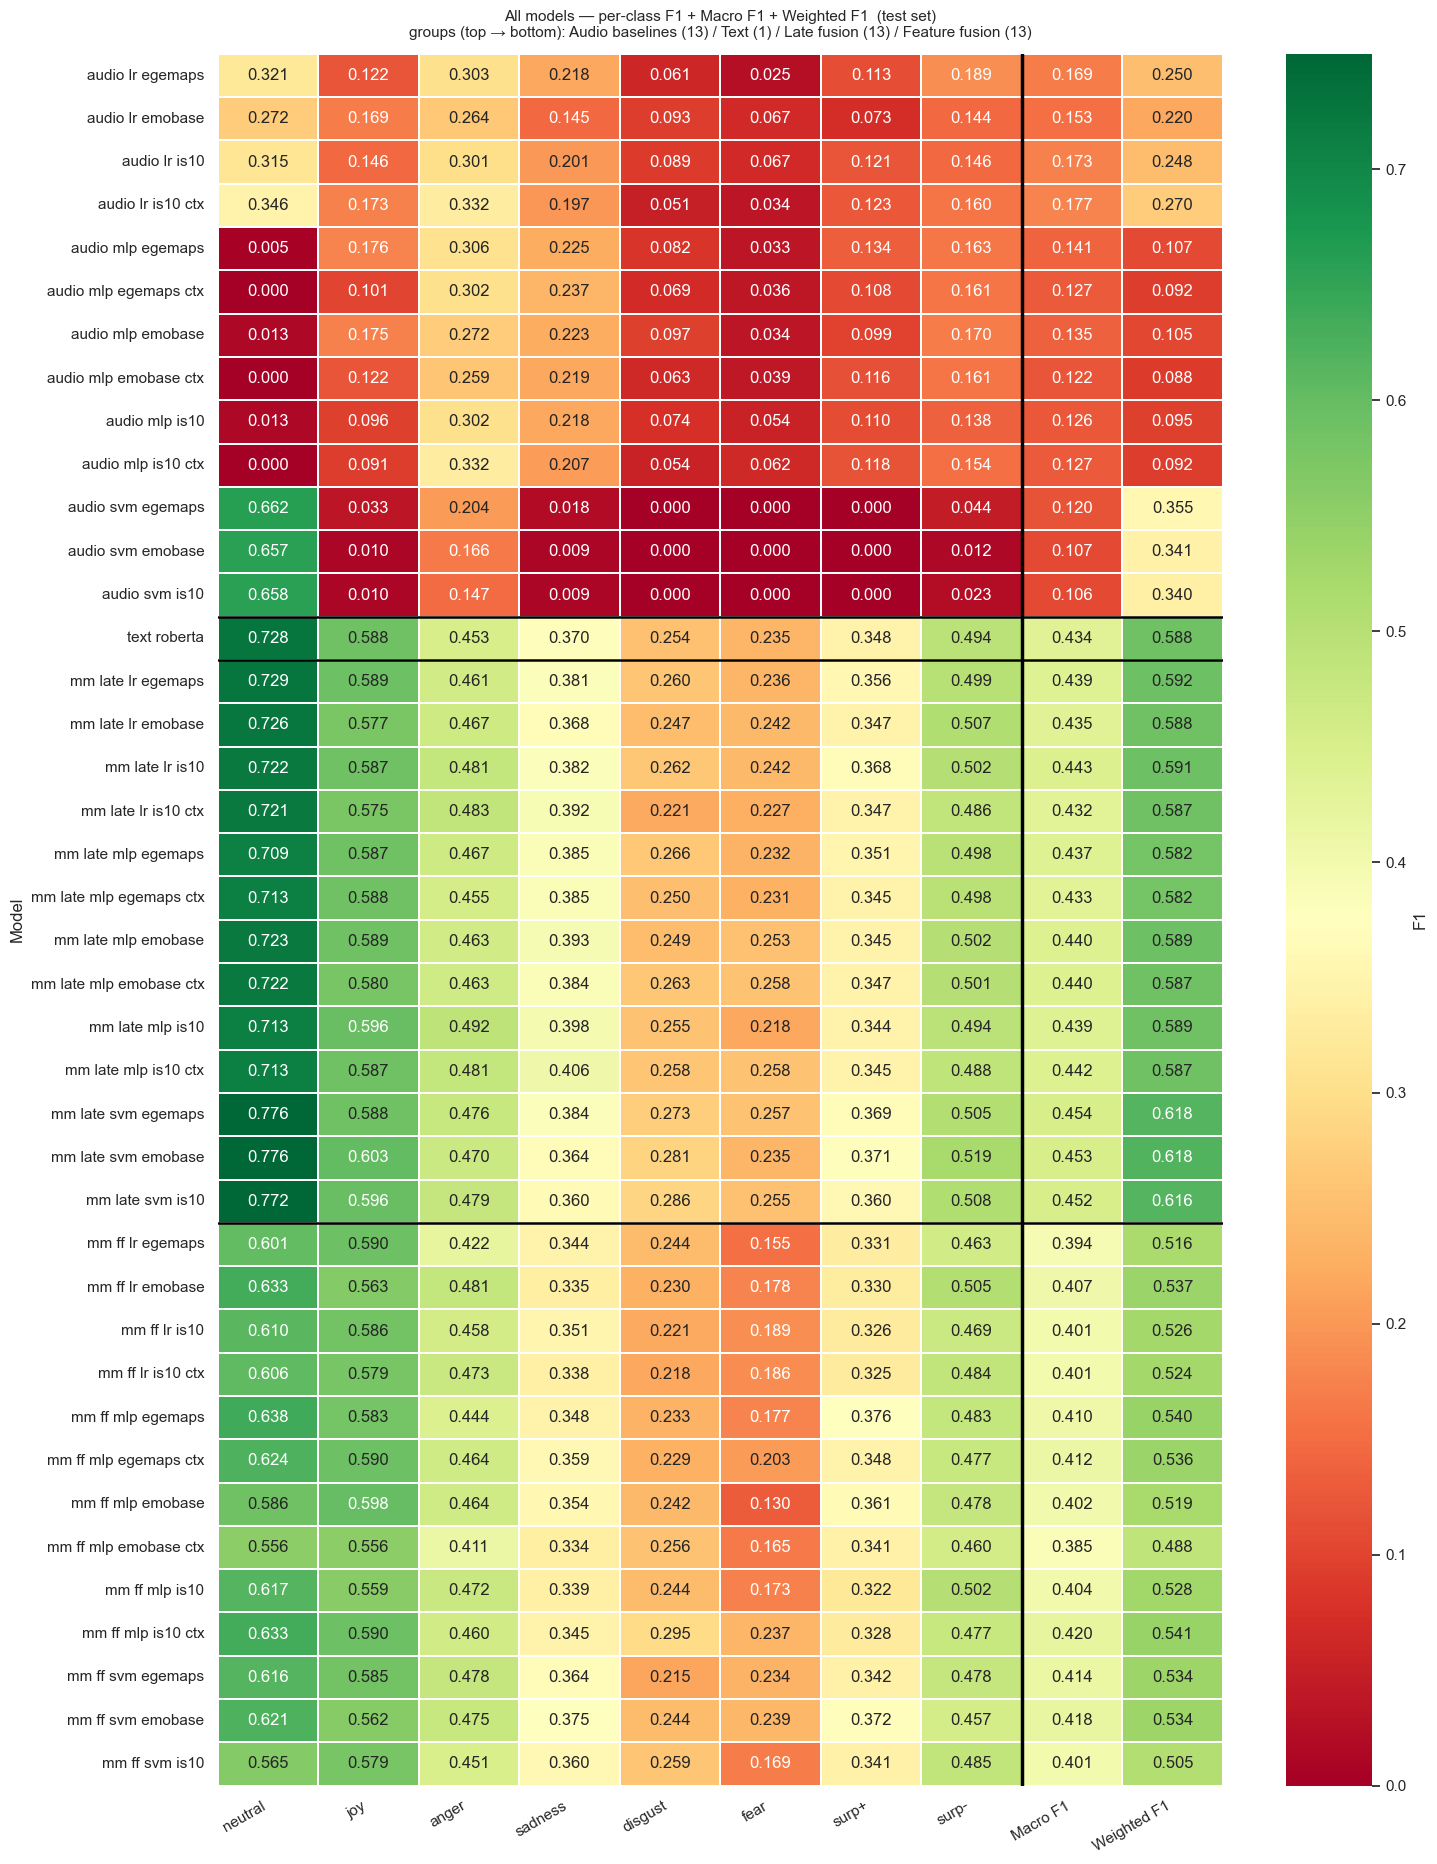

Best of each group (by macro F1):
  Audio baselines    audio_lr_is10_ctx                    mF1=0.1770  wF1=0.2702
  Text               text_roberta                         mF1=0.4338  wF1=0.5879
  Late fusion        mm_late_svm_egemaps                  mF1=0.4535  wF1=0.6178
  Feature fusion     mm_ff_mlp_is10_ctx                   mF1=0.4205  wF1=0.5408


In [21]:
# Collect every model's per-class + summary metrics into one big table.
_ALL_GROUPS = {
    'Audio baselines':  sorted(p.stem.replace('_softmax_test', '') for p in PREDICTIONS_DIR.glob('audio_*_softmax_test.npy')),
    'Text':             ['text_roberta'],
    'Late fusion':      sorted(p.stem.replace('_softmax_test', '') for p in PREDICTIONS_DIR.glob(f'{LATE_PREFIX}_*_softmax_test.npy')),
    'Feature fusion':   sorted(p.stem.replace('_softmax_test', '') for p in PREDICTIONS_DIR.glob(f'{FF_PREFIX}_*_softmax_test.npy')),
}

_class_cols = list(COL_NAMES.values())
_table_rows = []
_group_boundaries = []   # y-positions for thick horizontal lines
_cumulative = 0
_group_labels = []

for _gname, _tags in _ALL_GROUPS.items():
    _kept = 0
    for _tag in _tags:
        _p = get_metrics_path(_tag)
        if not _p.exists():
            continue
        _m   = json.loads(_p.read_text())
        _row = {'Model': _tag.replace('_', ' ')}
        for c in EMOTION_LABELS:
            _row[COL_NAMES[c]] = _m['per_class'][c]['f1']
        _row['Macro F1']    = _m['macro_f1']
        _row['Weighted F1'] = _m['weighted_f1']
        _table_rows.append(_row)
        _kept += 1
    if _kept > 0:
        _cumulative += _kept
        _group_boundaries.append(_cumulative)
        _group_labels.append(f'{_gname} ({_kept})')

df_all = pd.DataFrame(_table_rows).set_index('Model')

fig, ax = plt.subplots(figsize=(15, 0.42 * len(df_all) + 2))
sns.heatmap(df_all, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.0, vmax=0.75, linewidths=0.3, ax=ax,
            cbar_kws={'label': 'F1'})

# Vertical line separating per-class from summary cols
ax.axvline(len(_class_cols), color='black', linewidth=2.5)
# Horizontal lines separating groups
for _b in _group_boundaries[:-1]:
    ax.axhline(_b, color='black', linewidth=1.8)

ax.set_title('All models — per-class F1 + Macro F1 + Weighted F1  (test set)\n'
             f'groups (top → bottom): {" / ".join(_group_labels)}',
             fontsize=11, pad=12)
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'all_models_full_table.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary: best per category ────────────────────────────────────────────────
print('Best of each group (by macro F1):')
_offset = 0
for _gname, _tags in _ALL_GROUPS.items():
    _group_metrics = []
    for _t in _tags:
        _p = get_metrics_path(_t)
        if _p.exists():
            _m = json.loads(_p.read_text())
            _group_metrics.append((_m['macro_f1'], _m['weighted_f1'], _t))
    if _group_metrics:
        _group_metrics.sort(reverse=True)
        _best_mf1, _best_wf1, _best_tag = _group_metrics[0]
        print(f'  {_gname:18s} {_best_tag:35s}  mF1={_best_mf1:.4f}  wF1={_best_wf1:.4f}')

## 8 · Explainability & Insights

Four targeted analyses on the best models trained in sections 5–7. The goal is to move past aggregate F1 numbers and answer concrete questions:

1. **8.1 · Audio features** — Which acoustic measurements actually drive each emotion in the LR audio model? (LR coefficient inspection)
2. **8.2 · Confusion patterns** — Where do audio, text, and fusion disagree? (per-model normalized confusion matrices side-by-side)
3. **8.3 · Modality contribution** — In the feature-fusion MLP, how much does each modality contribute to each emotion class? (ablation by replacing one modality with its training mean)
4. **8.4 · Audio help vs hurt** — Which utterances did fusion rescue from text errors, and which did it break? (per-class help/hurt counts + example utterances)

The cells auto-detect the best model in each category from the saved metrics — re-run safely after retraining.

### 8.1 · Which acoustic features matter? (LR coefficients)

For the best Logistic Regression audio model, the per-class coefficients directly show which acoustic features increase (red) or decrease (blue) the predicted probability of each emotion. Features are sorted by maximum absolute coefficient across classes, so the most globally influential acoustic measurements rise to the top of the heatmap.

For IS10 (1582 features), only the top 40 by max |coef| are shown — the rest carry negligible weight in the trained model anyway.

Best LR audio: audio_lr_is10  mF1=0.1732
Feature set: is10 (1582 features)


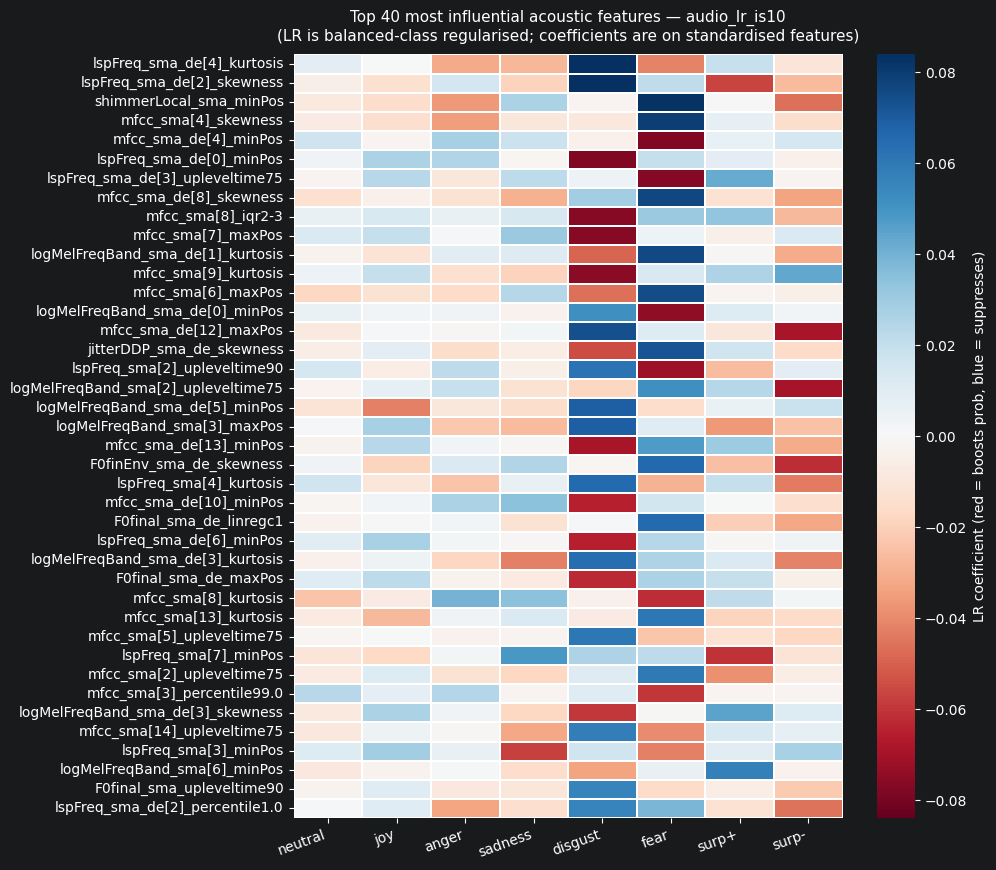


Top-5 most positive (boosting) features per emotion:
  neutral             logMelFreqBand_sma[1]_upleveltime90 (+0.040), shimmerLocal_sma_de_upleveltime90 (+0.034), shimmerLocal_sma_de_upleveltime75 (+0.031), mfcc_sma[10]_minPos (+0.030), logMelFreqBand_sma[1]_upleveltime75 (+0.029)
  joy                 logMelFreqBand_sma[2]_upleveltime90 (+0.043), mfcc_sma[7]_linregc2 (+0.042), mfcc_sma[4]_quartile3 (+0.036), mfcc_sma_de[10]_linregc2 (+0.034), F0finEnv_sma_minPos (+0.034)
  anger               mfcc_sma[10]_minPos (+0.047), mfcc_sma[1]_kurtosis (+0.046), logMelFreqBand_sma_de[2]_upleveltime75 (+0.041), mfcc_sma[8]_kurtosis (+0.040), logMelFreqBand_sma_de[1]_percentile1.0 (+0.036)
  sadness             jitterDDP_sma_minPos (+0.056), mfcc_sma[13]_iqr1-2 (+0.053), pcm_loudness_sma_maxPos (+0.051), jitterLocal_sma_de_skewness (+0.051), lspFreq_sma[7]_minPos (+0.049)
  disgust             lspFreq_sma_de[4]_kurtosis (+0.084), lspFreq_sma_de[2]_skewness (+0.084), mfcc_sma_de[12]_maxPos (+0.

In [22]:
# Find best LR audio model (excluding ctx variants for clarity)
_lr_metrics = [(json.loads(p.read_text())['macro_f1'], p.stem)
               for p in METRICS_DIR.glob('audio_lr_*.json')
               if 'ctx' not in p.stem]
_best_lr_mf1, _best_lr_tag = max(_lr_metrics, key=lambda x: x[0])
print(f'Best LR audio: {_best_lr_tag}  mF1={_best_lr_mf1:.4f}')

# Load model and feature names
with open(get_model_path(_best_lr_tag), 'rb') as _f:
    _lr_clf = pickle.load(_f)
_feature_set = _best_lr_tag.split('_')[-1]
_feat_df = pd.read_parquet(FEATURES_DIR / f'train_{_feature_set}.parquet')
_feat_cols = [c for c in _feat_df.columns
              if c not in {'dialogue_id', 'utterance_id', 'label_idx'}]
print(f'Feature set: {_feature_set} ({len(_feat_cols)} features)')

# Map LR's coef_ (rows = present classes) to NUM_CLASSES rows
_coef = np.zeros((NUM_CLASSES, len(_feat_cols)))
for _i, _c in enumerate(_lr_clf.classes_):
    _coef[_c] = _lr_clf.coef_[_i]

# Pick top-N features by max absolute coefficient across classes
_TOP_N    = min(40, len(_feat_cols))
_max_abs  = np.max(np.abs(_coef), axis=0)
_top_idx  = np.argsort(_max_abs)[-_TOP_N:][::-1]
_top_names = [_feat_cols[i] for i in _top_idx]
_top_coef  = _coef[:, _top_idx]

# Heatmap: features (rows) × emotions (cols)
fig, ax = plt.subplots(figsize=(10, max(6, _TOP_N * 0.22)))
_vmax = np.abs(_top_coef).max()
sns.heatmap(_top_coef.T,
            yticklabels=_top_names,
            xticklabels=[COL_NAMES[c] for c in EMOTION_LABELS],
            cmap='RdBu', center=0, vmin=-_vmax, vmax=_vmax,
            linewidths=0.2, ax=ax,
            cbar_kws={'label': 'LR coefficient (red = boosts prob, blue = suppresses)'})
ax.set_title(f'Top {_TOP_N} most influential acoustic features — {_best_lr_tag}\n'
             f'(LR is balanced-class regularised; coefficients are on standardised features)',
             fontsize=11, pad=10)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# Print per-emotion top-5 features as a quick lookup
print('\nTop-5 most positive (boosting) features per emotion:')
for _i, _label in enumerate(EMOTION_LABELS):
    _idx_sorted = np.argsort(_coef[_i])[-5:][::-1]
    _items = ', '.join(f'{_feat_cols[_j]} (+{_coef[_i, _j]:.3f})' for _j in _idx_sorted)
    print(f'  {_label:18s}  {_items}')

### 8.2 · Confusion patterns across modalities

Row-normalised confusion matrices for the four "champion" models — best audio, text, best late fusion, best feature fusion. Reading a row tells you what an utterance with that true label gets predicted as.

What to look for:
- **Diagonal mass**: how much of each class the model actually catches
- **Off-diagonal hotspots**: systematic confusions (e.g. "joy → neutral" or "fear → anger")
- **Differences between modalities**: where audio sees patterns text misses, and vice versa

Best audio   : audio_lr_is10_ctx
Best late    : mm_late_svm_egemaps
Best feature : mm_ff_mlp_is10_ctx


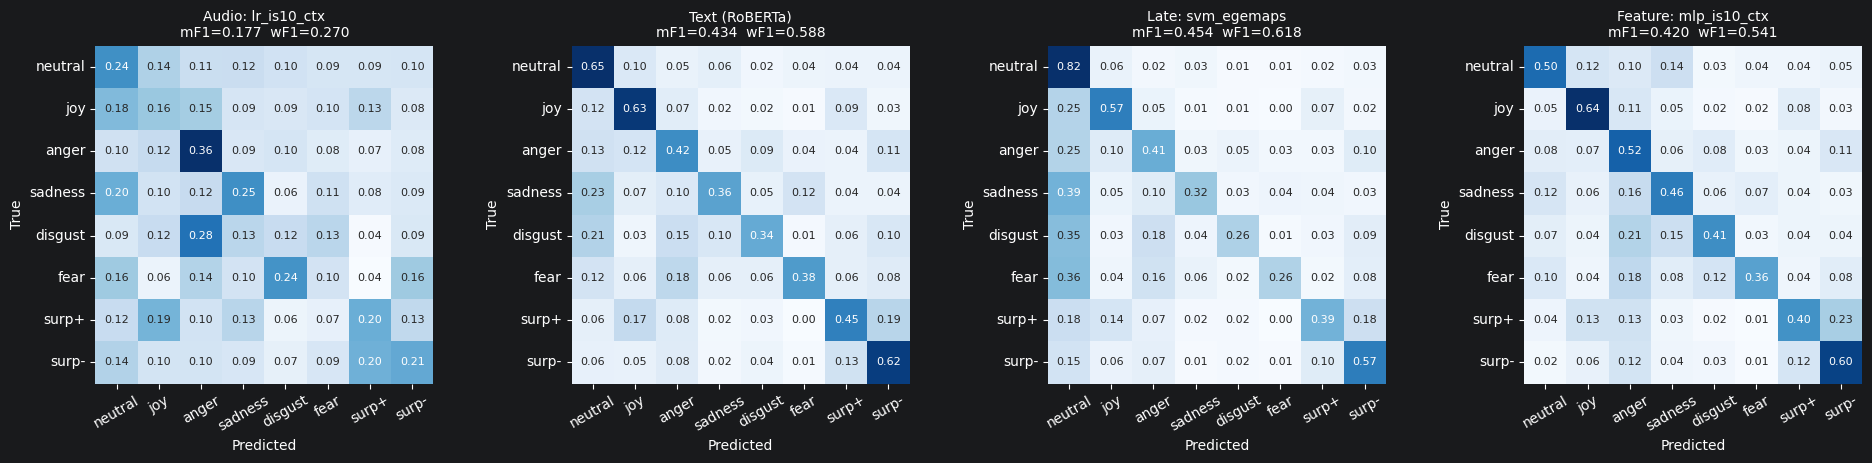

In [23]:
from sklearn.metrics import confusion_matrix

# Pick best model from each category by macro F1
def _best_in(glob_pat):
    rows = [(json.loads(p.read_text())['macro_f1'], p.stem)
            for p in METRICS_DIR.glob(glob_pat)]
    return max(rows, key=lambda x: x[0])[1] if rows else None

_best_audio = _best_in('audio_*.json')
_best_late  = _best_in('mm_late_*.json')
_best_ff    = _best_in('mm_ff_*.json')
print(f'Best audio   : {_best_audio}')
print(f'Best late    : {_best_late}')
print(f'Best feature : {_best_ff}')

_models = [('Audio: ' + _best_audio.replace('audio_', ''), _best_audio),
           ('Text (RoBERTa)',                              'text_roberta')]
if _best_late:
    _models.append((f'Late: {_best_late.replace("mm_late_", "")}', _best_late))
if _best_ff:
    _models.append((f'Feature: {_best_ff.replace("mm_ff_", "")}', _best_ff))

_y_test = test_df['label_idx'].values.astype(int)
_short  = [COL_NAMES[c] for c in EMOTION_LABELS]

fig, axes = plt.subplots(1, len(_models), figsize=(4.8 * len(_models), 4.5))
if len(_models) == 1:
    axes = [axes]
for _ax, (_title, _tag) in zip(axes, _models):
    _sf   = np.load(get_prediction_path(_tag, 'test'))
    _pred = _sf.argmax(1)
    _cm   = confusion_matrix(_y_test, _pred, labels=range(NUM_CLASSES), normalize='true')
    sns.heatmap(_cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=_short, yticklabels=_short, ax=_ax,
                cbar=False, square=True, annot_kws={'size': 8})
    _m   = json.loads(get_metrics_path(_tag).read_text())
    _ax.set_title(f'{_title}\nmF1={_m["macro_f1"]:.3f}  wF1={_m["weighted_f1"]:.3f}',
                  fontsize=10)
    _ax.set_xlabel('Predicted')
    _ax.set_ylabel('True')
    _ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 · Modality contribution per emotion (ablation)

For the best feature-fusion MLP: replace the audio softmax with its **training mean** (= "no informative audio") and re-predict; do the same for the CLS embeddings. The drop in predicted probability for the true class measures how much each modality was contributing.

A class where removing audio drops probability sharply → **audio drives that class**.
A class where removing text drops probability sharply → **text drives that class**.

> Requires section 6.1 (helpers + CLS scaler) to have been executed first.

Ablating mm_ff_mlp_is10_ctx  (audio branch: audio_mlp_is10_ctx)
[WARN] Dropped 6 row(s) with NaN values from train_is10.parquet (train/is10).


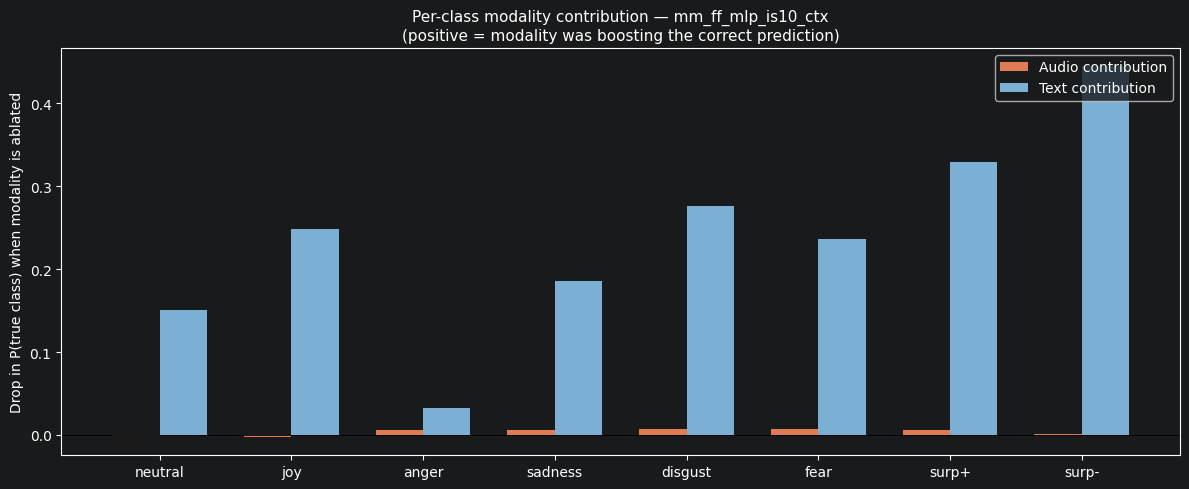


Per-class modality contribution (Δ P(true class) when ablated):
Class                   Audio Δ     Text Δ    Ratio (T/A)
neutral                 -0.0015    +0.1505         -97.99
joy                     -0.0022    +0.2484        -114.73
anger                   +0.0064    +0.0330           5.12
sadness                 +0.0061    +0.1855          30.38
disgust                 +0.0077    +0.2759          35.86
fear                    +0.0076    +0.2361          31.14
surprise_positive       +0.0063    +0.3299          52.49
surprise_negative       +0.0012    +0.4446         371.25


In [24]:
# Modality ablation on the best feature-fusion MLP.
if not _best_ff:
    print('No feature fusion model found — run section 6.2 first.')
else:
    _audio_short = _best_ff.replace('mm_ff_', '')
    _audio_for_ff = f'audio_{_audio_short}'
    print(f'Ablating {_best_ff}  (audio branch: {_audio_for_ff})')

    # Load model
    _hp = json.loads(get_hparams_path(_best_ff).read_text())
    _model = FusionMLP(INPUT_DIM, [_hp['hidden_1'], _hp['hidden_2']], _hp['dropout']).to(DEVICE)
    _model.load_state_dict(torch.load(get_model_path(_best_ff), map_location=DEVICE))
    _model.eval()

    # Rebuild inputs (audio softmax must match the model used in this MLP)
    _audio_te    = get_audio_softmax(_audio_for_ff, 'test',  test_df)
    _audio_train = get_audio_softmax(_audio_for_ff, 'train', train_df)

    _mean_audio = _audio_train.mean(axis=0, keepdims=True)
    _mean_cls   = cls_train_sc.mean(axis=0, keepdims=True)
    _N = len(_audio_te)

    _X_full     = np.concatenate([_audio_te,                         cls_test_sc],                       axis=1)
    _X_no_audio = np.concatenate([np.tile(_mean_audio, (_N, 1)),    cls_test_sc],                       axis=1)
    _X_no_text  = np.concatenate([_audio_te,                         np.tile(_mean_cls, (_N, 1))],      axis=1)

    def _predict_softmax(X):
        with torch.no_grad():
            return F.softmax(_model(torch.tensor(X, dtype=torch.float32).to(DEVICE)),
                             dim=1).cpu().numpy()

    _p_full   = _predict_softmax(_X_full)
    _p_no_aud = _predict_softmax(_X_no_audio)
    _p_no_txt = _predict_softmax(_X_no_text)

    # For each class c, compute the average drop in P(c) for utterances whose TRUE label is c
    # when audio (or text) is replaced with its mean.
    _audio_contrib = np.zeros(NUM_CLASSES)
    _text_contrib  = np.zeros(NUM_CLASSES)
    _y_test = test_df['label_idx'].values.astype(int)
    for _c in range(NUM_CLASSES):
        _mask = _y_test == _c
        if _mask.sum() == 0:
            continue
        _audio_contrib[_c] = (_p_full[_mask, _c] - _p_no_aud[_mask, _c]).mean()
        _text_contrib[_c]  = (_p_full[_mask, _c] - _p_no_txt[_mask, _c]).mean()

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    _x = np.arange(NUM_CLASSES)
    _w = 0.36
    ax.bar(_x - _w/2, _audio_contrib, _w, label='Audio contribution', color='#e07b54')
    ax.bar(_x + _w/2, _text_contrib,  _w, label='Text contribution',  color='#7bafd4')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(_x)
    ax.set_xticklabels([COL_NAMES[c] for c in EMOTION_LABELS])
    ax.set_ylabel('Drop in P(true class) when modality is ablated')
    ax.set_title(f'Per-class modality contribution — {_best_ff}\n'
                 f'(positive = modality was boosting the correct prediction)',
                 fontsize=11)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_modality_ablation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print summary
    print('\nPer-class modality contribution (Δ P(true class) when ablated):')
    print(f'{"Class":<20} {"Audio Δ":>10} {"Text Δ":>10} {"Ratio (T/A)":>14}')
    for _c, _label in enumerate(EMOTION_LABELS):
        _r = _text_contrib[_c] / _audio_contrib[_c] if abs(_audio_contrib[_c]) > 1e-6 else float('inf')
        print(f'{_label:<20} {_audio_contrib[_c]:>+10.4f} {_text_contrib[_c]:>+10.4f} {_r:>14.2f}')

### 8.4 · Where does audio rescue text, and where does it break it?

For the best late-fusion model, split the test set into four buckets:
- **Audio rescued text** — text alone was wrong, fusion got it right
- **Audio broke text**    — text alone was right, fusion got it wrong
- **Both right**          — uninteresting
- **Both wrong**          — also uninteresting

The first two are where audio is actually doing work. Per-class counts show where audio adds genuine signal vs where it just shifts predictions toward majority (`neutral`).

A handful of example utterances are printed below so you can see the actual text the model is seeing.

Best late fusion : mm_late_svm_egemaps
Audio rescued text on :  228 / 2610 test utterances
Audio broke text on   :   84 / 2610 test utterances
Net effect            : +144


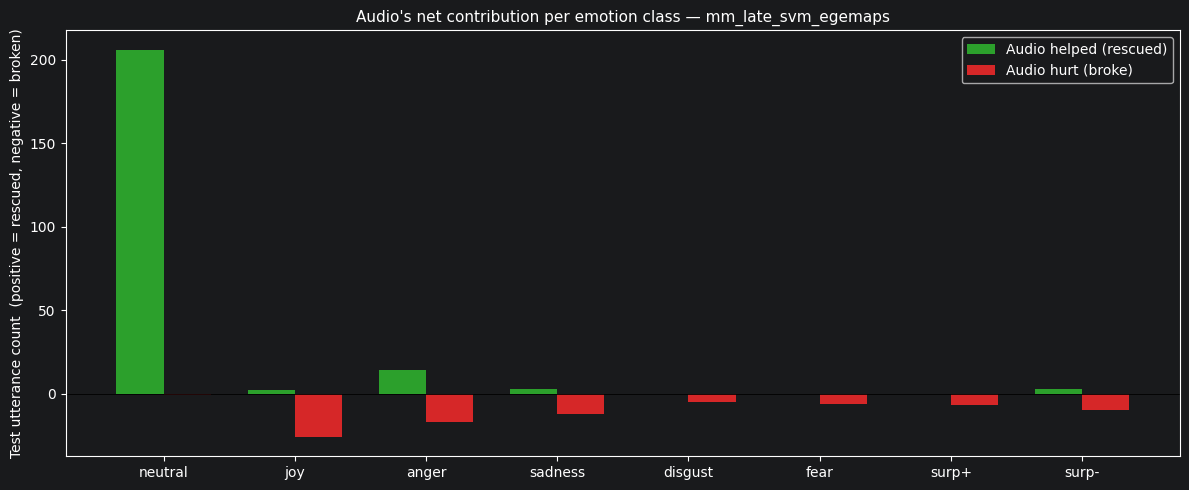


Per-class help/hurt counts:
Class                  helped     hurt      net   support
neutral                   206        1     +205      1256
joy                         2       26      -24       402
anger                      14       17       -3       345
sadness                     3       12       -9       208
disgust                     0        5       -5        68
fear                        0        6       -6        50
surprise_positive           0        7       -7       119
surprise_negative           3       10       -7       162

══ Audio HELPED (text wrong → fusion right) ══
  true=neutral            text→surprise_negative  (0.34)  "Okay. </s> Ross, didn't you say that there was an elevator in here?"
  true=neutral            text→surprise_positive  (0.44)  "Okay. </s> You got it?"
  true=neutral            text→sadness            (0.32)  "Howard's the </s> Yes but too me he's just, man."
  true=neutral            text→surprise_positive  (0.36)  "What's fish hooking? <

In [25]:
# Audio's net effect on the best late-fusion model.
if not _best_late:
    print('No late-fusion model found — run section 5 first.')
else:
    _text_sf  = np.load(get_prediction_path('text_roberta', 'test'))
    _late_sf  = np.load(get_prediction_path(_best_late, 'test'))
    _y_test   = test_df['label_idx'].values.astype(int)
    _text_pred = _text_sf.argmax(1)
    _late_pred = _late_sf.argmax(1)

    _text_correct = _text_pred == _y_test
    _late_correct = _late_pred == _y_test

    _audio_helped = _late_correct & ~_text_correct
    _audio_hurt   = ~_late_correct &  _text_correct

    print(f'Best late fusion : {_best_late}')
    print(f'Audio rescued text on : {_audio_helped.sum():>4d} / {len(_y_test)} test utterances')
    print(f'Audio broke text on   : {_audio_hurt.sum():>4d} / {len(_y_test)} test utterances')
    print(f'Net effect            : {_audio_helped.sum() - _audio_hurt.sum():>+4d}')

    # Per-class breakdown
    _help_per = np.zeros(NUM_CLASSES, dtype=int)
    _hurt_per = np.zeros(NUM_CLASSES, dtype=int)
    for _c in range(NUM_CLASSES):
        _mask = _y_test == _c
        _help_per[_c] = (_audio_helped & _mask).sum()
        _hurt_per[_c] = (_audio_hurt   & _mask).sum()

    fig, ax = plt.subplots(figsize=(12, 5))
    _x = np.arange(NUM_CLASSES)
    _w = 0.36
    ax.bar(_x - _w/2,  _help_per, _w, label='Audio helped (rescued)', color='#2ca02c')
    ax.bar(_x + _w/2, -_hurt_per, _w, label='Audio hurt (broke)',     color='#d62728')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(_x)
    ax.set_xticklabels([COL_NAMES[c] for c in EMOTION_LABELS])
    ax.set_ylabel('Test utterance count  (positive = rescued, negative = broken)')
    ax.set_title(f'Audio\'s net contribution per emotion class — {_best_late}',
                 fontsize=11)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_audio_help_hurt.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Per-class summary table
    print('\nPer-class help/hurt counts:')
    print(f'{"Class":<20} {"helped":>8} {"hurt":>8} {"net":>8}  {"support":>8}')
    for _c, _label in enumerate(EMOTION_LABELS):
        _supp = (_y_test == _c).sum()
        print(f'{_label:<20} {_help_per[_c]:>8d} {_hurt_per[_c]:>8d} {_help_per[_c]-_hurt_per[_c]:>+8d}  {_supp:>8d}')

    # Sample utterances
    _N_SHOW = 5
    _texts = test_df['text_with_context'].values
    print('\n══ Audio HELPED (text wrong → fusion right) ══')
    for _i in np.where(_audio_helped)[0][:_N_SHOW]:
        _true  = EMOTION_LABELS[_y_test[_i]]
        _twas  = EMOTION_LABELS[_text_pred[_i]]
        _tconf = _text_sf[_i, _text_pred[_i]]
        _snippet = _texts[_i][:130].replace('\n', ' ')
        print(f'  true={_true:<18s} text→{_twas:<18s} ({_tconf:.2f})  "{_snippet}"')

    print('\n══ Audio HURT (text right → fusion wrong) ══')
    for _i in np.where(_audio_hurt)[0][:_N_SHOW]:
        _true  = EMOTION_LABELS[_y_test[_i]]
        _twas  = EMOTION_LABELS[_text_pred[_i]]
        _lwas  = EMOTION_LABELS[_late_pred[_i]]
        _snippet = _texts[_i][:130].replace('\n', ' ')
        print(f'  true={_true:<18s} text→{_twas:<18s} fusion→{_lwas:<18s}  "{_snippet}"')

### 8.5 · Which acoustic *families* matter? (grouped LR coefficients)

The per-feature heatmap above is informative but noisy — 1582 IS10 features means each emotion has hundreds of small coefficients. Aggregating into descriptor families (F0, energy, MFCC, spectral, voicing, jitter/shimmer) gives a more interpretable picture of *what the audio model is listening to* for each emotion.


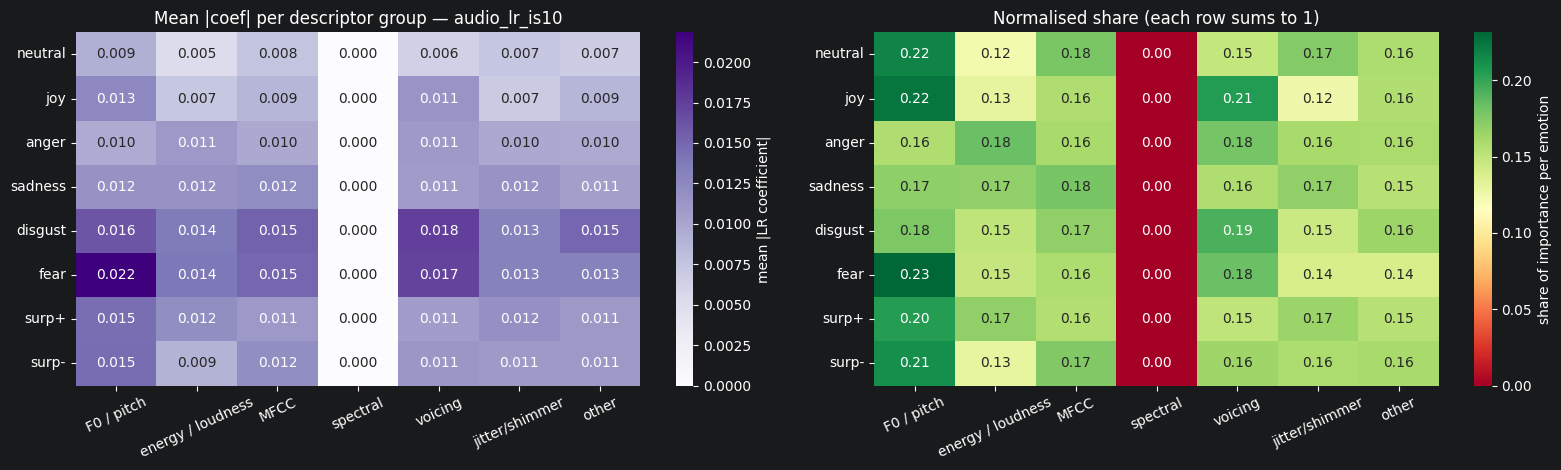

Feature-group population in feature set 'is10':
  F0 / pitch                82
  energy / loudness         42
  MFCC                     630
  spectral                   0
  voicing                   42
  jitter/shimmer           114
  other                    672
  TOTAL                   1582

Dominant descriptor group per emotion (by mean |coef|):
  neutral              → F0 / pitch
  joy                  → F0 / pitch
  anger                → energy / loudness
  sadness              → MFCC
  disgust              → voicing
  fear                 → F0 / pitch
  surprise_positive    → F0 / pitch
  surprise_negative    → F0 / pitch


In [26]:
# Aggregate the best LR audio model's coefficients into descriptor families.
# Re-uses _best_lr_tag, _feat_cols and _coef computed in section 8.1.

def _audio_group(name: str) -> str:
    n = name.lower()
    if 'jitter' in n or 'shimmer' in n:
        return 'jitter/shimmer'
    if 'mfcc' in n:
        return 'MFCC'
    if 'f0' in n or 'pitch' in n:
        return 'F0 / pitch'
    if 'voic' in n or 'hnr' in n:
        return 'voicing'
    if any(k in n for k in ('loudness', 'rmsenergy', 'intensity', 'energy', 'equivalentsound')):
        return 'energy / loudness'
    if any(k in n for k in ('audspec', 'spectral', 'fftmag', 'formant', 'hammarberg', 'slope', 'harmoni', 'logmel', 'melfreq', 'lspfreq', 'lsp_', 'zcr')):
        return 'spectral'
    return 'other'

_groups       = ['F0 / pitch', 'energy / loudness', 'MFCC', 'spectral',
                 'voicing', 'jitter/shimmer', 'other']
_feat_groups  = np.array([_audio_group(c) for c in _feat_cols])
_group_counts = pd.Series(_feat_groups).value_counts().reindex(_groups, fill_value=0)

# Aggregate mean |coef| per group × emotion (mean handles uneven group sizes)
_abs_coef  = np.abs(_coef)
_group_imp = np.zeros((NUM_CLASSES, len(_groups)))
for gi, g in enumerate(_groups):
    mask = _feat_groups == g
    if mask.sum() == 0:
        continue
    _group_imp[:, gi] = _abs_coef[:, mask].mean(axis=1)

# Row-normalise to make per-emotion shares comparable
_group_frac = _group_imp / _group_imp.sum(axis=1, keepdims=True).clip(min=1e-9)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
_short = [COL_NAMES[c] for c in EMOTION_LABELS]

sns.heatmap(_group_imp, annot=True, fmt='.3f', cmap='Purples',
            xticklabels=_groups, yticklabels=_short, ax=axes[0],
            cbar_kws={'label': 'mean |LR coefficient|'})
axes[0].set_title(f'Mean |coef| per descriptor group — {_best_lr_tag}')
axes[0].set_xlabel(''); axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=25)

sns.heatmap(_group_frac, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=_groups, yticklabels=_short, ax=axes[1],
            vmin=0, vmax=float(_group_frac.max()),
            cbar_kws={'label': 'share of importance per emotion'})
axes[1].set_title('Normalised share (each row sums to 1)')
axes[1].set_xlabel(''); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_audio_feature_groups.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Feature-group population in feature set {_best_lr_tag.split("_")[-1]!r}:')
for g, n in _group_counts.items():
    print(f'  {g:<22s} {n:>5d}')
print(f'  {"TOTAL":<22s} {_group_counts.sum():>5d}')

print('\nDominant descriptor group per emotion (by mean |coef|):')
for i, lbl in enumerate(EMOTION_LABELS):
    top_g = _groups[int(np.argmax(_group_imp[i]))]
    print(f'  {lbl:<20s} → {top_g}')


### 8.6 · Which *tokens* drive RoBERTa? (Integrated Gradients)

We attribute the target-class logit to each input token by running Integrated Gradients on the word-embedding layer.  The path is a straight line from a pad-token baseline to the actual embeddings, integrated in `IG_STEPS` Riemann steps. For each emotion we pick the highest-confidence correctly-classified utterances and look at:

1. **Top tokens per emotion** — tokens with the largest positive attribution toward    the true label, aggregated across examples.
2. **Per-sample colour bars** — one example per emotion, every token coloured by its    IG score (orange = pushes toward the true label, blue = away).


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running IG on 32 examples (steps=20, max_len=64)...


neutral:   0%|          | 0/4 [00:00<?, ?it/s]

joy:   0%|          | 0/4 [00:00<?, ?it/s]

anger:   0%|          | 0/4 [00:00<?, ?it/s]

sadness:   0%|          | 0/4 [00:00<?, ?it/s]

disgust:   0%|          | 0/4 [00:00<?, ?it/s]

fear:   0%|          | 0/4 [00:00<?, ?it/s]

surprise_positive:   0%|          | 0/4 [00:00<?, ?it/s]

surprise_negative:   0%|          | 0/4 [00:00<?, ?it/s]

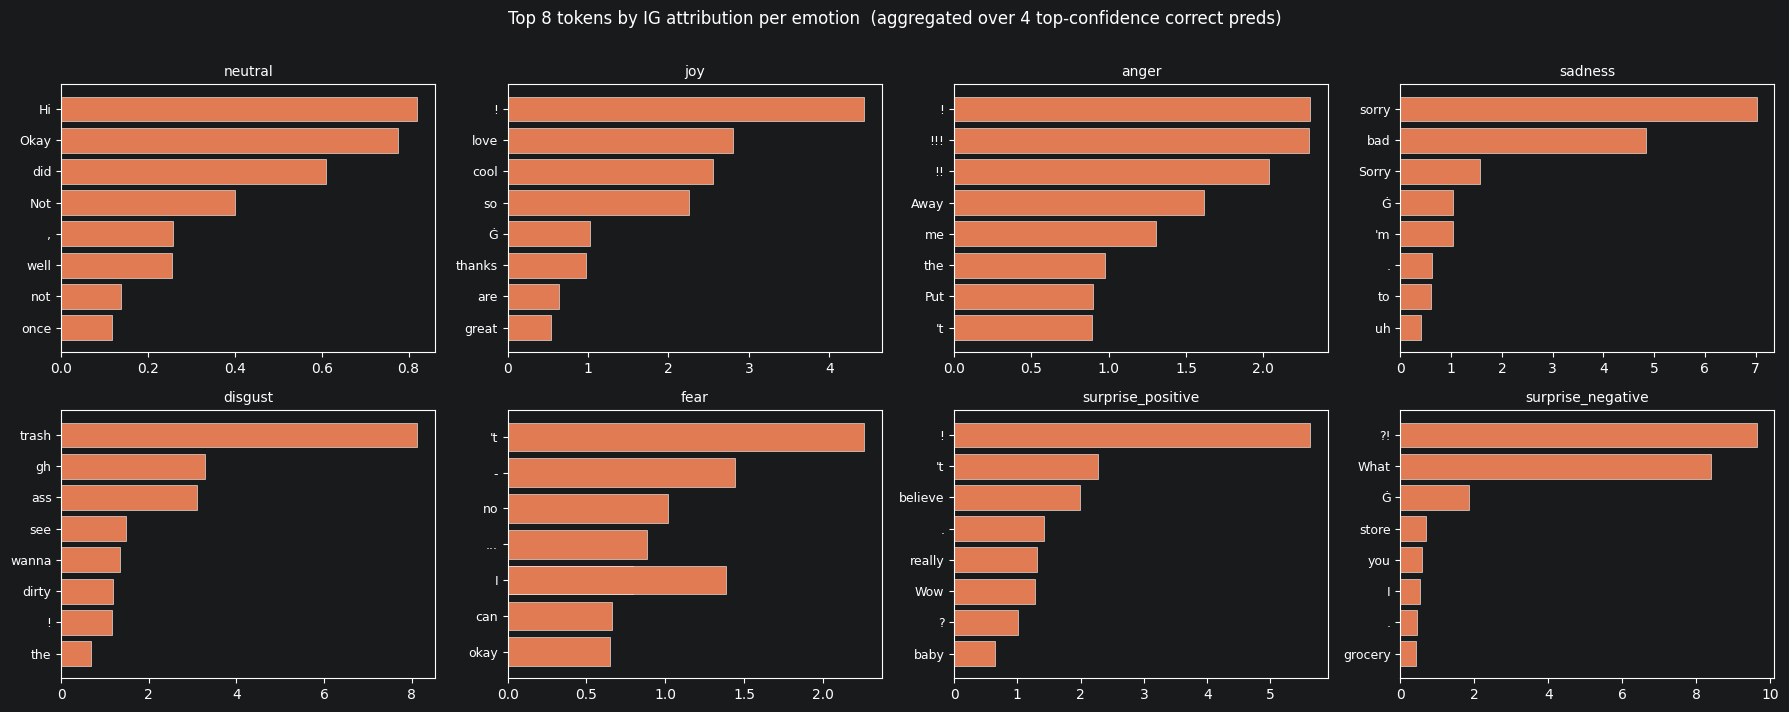

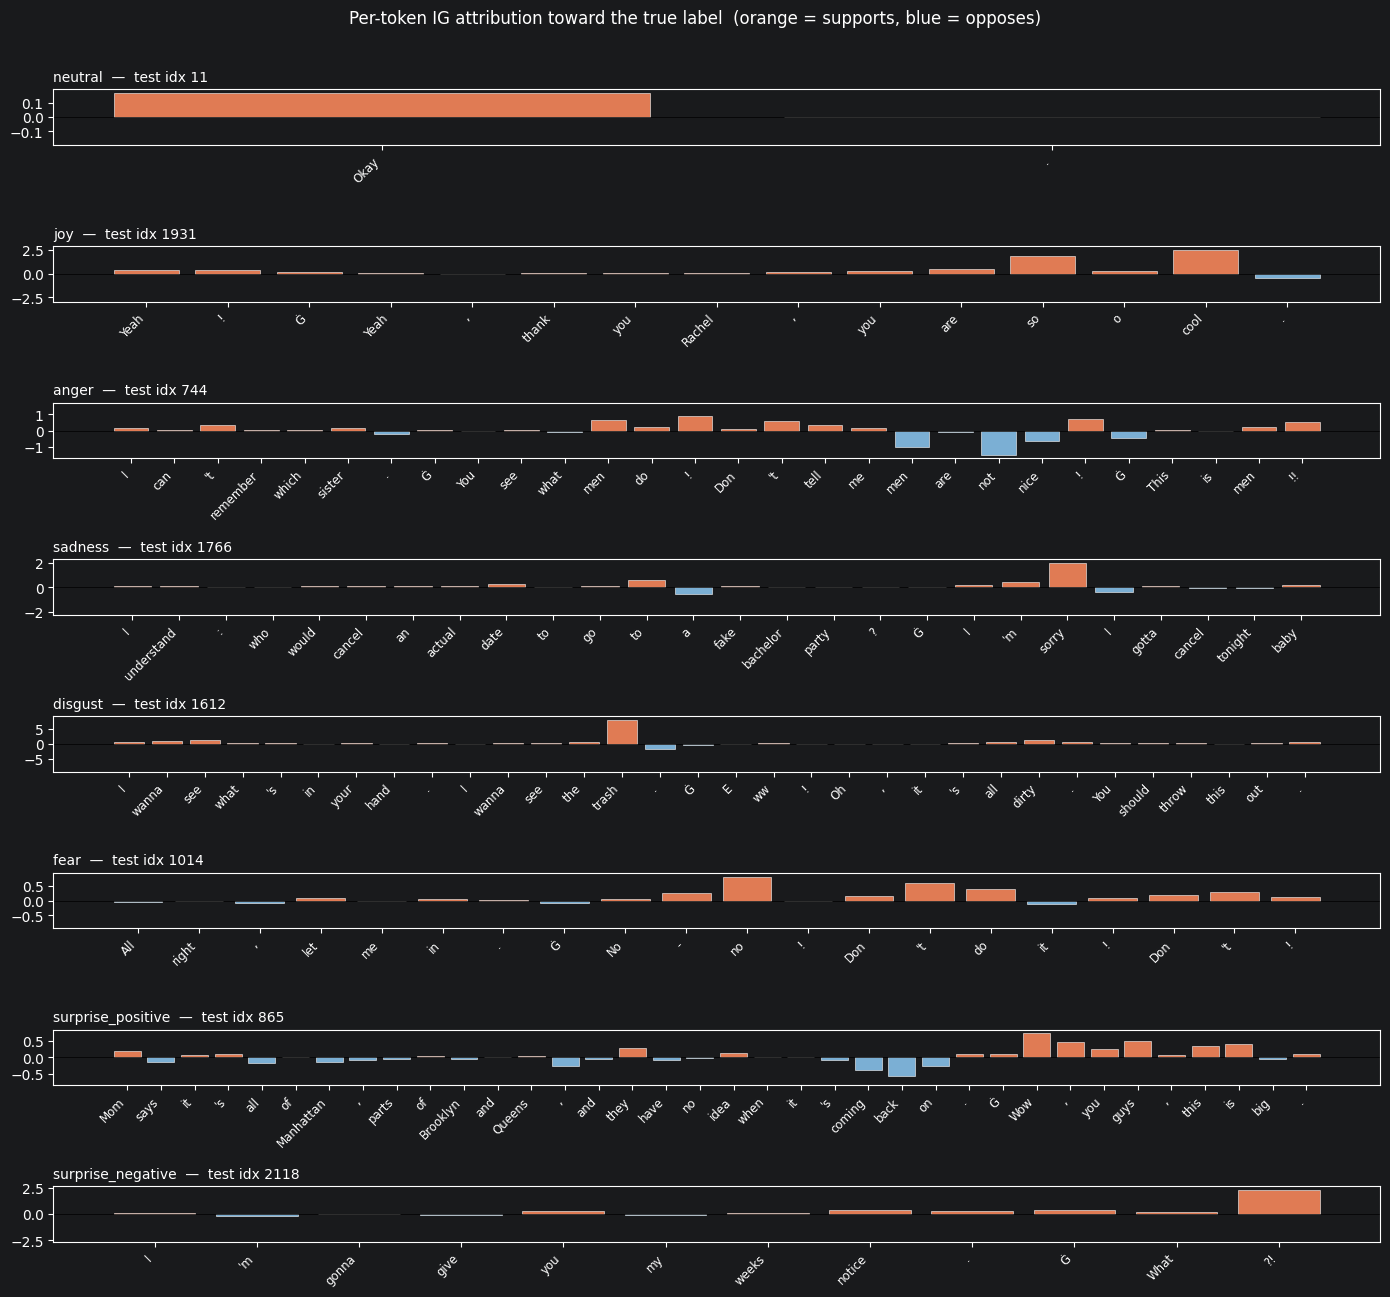

In [27]:
# Manual Integrated Gradients on RoBERTa embeddings.
# No captum dependency: we run forward/backward with `inputs_embeds`.

from transformers import AutoModelForSequenceClassification, RobertaTokenizer

IG_N_PER_CLASS = 4    # examples to attribute per emotion
IG_STEPS       = 20   # Riemann steps
IG_MAX_LEN     = 64   # cap length to keep memory bounded

_ig_tok   = RobertaTokenizer.from_pretrained(ROBERTA_SOURCE)
_ig_model = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_SOURCE, num_labels=NUM_CLASSES
).to(DEVICE).eval()
_word_emb = _ig_model.roberta.embeddings.word_embeddings


def _integrated_gradients(text, target_class, steps=IG_STEPS, max_len=IG_MAX_LEN):
    enc = _ig_tok(text, return_tensors='pt', padding='max_length',
                  truncation=True, max_length=max_len)
    input_ids = enc['input_ids'].to(DEVICE)
    attn      = enc['attention_mask'].to(DEVICE)
    with torch.no_grad():
        input_embeds = _word_emb(input_ids)
        base_embeds  = _word_emb(torch.full_like(input_ids, _ig_tok.pad_token_id))
    delta = input_embeds - base_embeds
    grads = torch.zeros_like(input_embeds)
    for s in range(1, steps + 1):
        alpha  = s / steps
        interp = (base_embeds + alpha * delta).detach().requires_grad_(True)
        logits = _ig_model(inputs_embeds=interp, attention_mask=attn).logits
        target = logits[0, target_class]
        g      = torch.autograd.grad(target, interp)[0]
        grads  = grads + g
    grads = grads / steps
    ig    = (delta * grads).sum(dim=-1).squeeze(0).cpu().numpy()
    tokens = _ig_tok.convert_ids_to_tokens(input_ids[0].cpu().tolist())
    mask   = attn[0].cpu().numpy().astype(bool)
    return tokens, ig, mask


# Pick examples: highest-confidence *correct* text predictions per emotion
_text_sf_ig  = np.load(get_prediction_path('text_roberta', 'test'))
_text_pred_ig = _text_sf_ig.argmax(1)
_y_test_ig    = test_df['label_idx'].values.astype(int)
_text_correct_ig = _text_pred_ig == _y_test_ig

_examples = {}
for _c in range(NUM_CLASSES):
    _mask = _text_correct_ig & (_y_test_ig == _c)
    if _mask.sum() == 0:
        _examples[_c] = []
        continue
    _pool = np.where(_mask)[0]
    _conf = _text_sf_ig[_pool, _c]
    _examples[_c] = _pool[np.argsort(_conf)[::-1][:IG_N_PER_CLASS]].tolist()

# Run IG on every chosen example
_token_agg  = {c: {} for c in range(NUM_CLASSES)}
_first_per_class = {}    # one (tokens, ig, mask, idx) per emotion for the bar panel
_texts_all  = test_df['text_with_context'].values

print(f'Running IG on {sum(len(v) for v in _examples.values())} examples '
      f'(steps={IG_STEPS}, max_len={IG_MAX_LEN})...')
for _c, _idxs in _examples.items():
    for _rank, _i in enumerate(tqdm(_idxs, desc=EMOTION_LABELS[_c], leave=False)):
        toks, ig_vals, mask = _integrated_gradients(_texts_all[_i], _c)
        if _rank == 0:
            _first_per_class[_c] = (toks, ig_vals, mask, int(_i))
        for t, v, m in zip(toks, ig_vals, mask):
            if not m or t in ('<s>', '</s>', '<pad>'):
                continue
            _token_agg[_c][t] = _token_agg[_c].get(t, 0.0) + float(v)

del _ig_model
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()

# === Panel 1: top-K tokens per emotion ===
_TOP_K = 8
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, lbl, c in zip(axes.flat, EMOTION_LABELS, range(NUM_CLASSES)):
    items = sorted(_token_agg[c].items(), key=lambda x: x[1], reverse=True)[:_TOP_K]
    if not items:
        ax.set_title(f'{lbl}  (no examples)', fontsize=10); ax.axis('off'); continue
    names = [t.lstrip('Ġ').lstrip('▁') or t for t, _ in items][::-1]
    vals  = [v for _, v in items][::-1]
    ax.barh(names, vals, color='#e07b54', edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(f'{lbl}', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)
plt.suptitle(f'Top {_TOP_K} tokens by IG attribution per emotion  '
             f'(aggregated over {IG_N_PER_CLASS} top-confidence correct preds)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_text_top_tokens.png',
            dpi=150, bbox_inches='tight')
plt.show()

# === Panel 2: per-sample token bars (one example per emotion) ===
_n_shown = sum(1 for c in range(NUM_CLASSES) if c in _first_per_class)
fig, axes = plt.subplots(_n_shown, 1, figsize=(14, 1.6 * _n_shown))
if _n_shown == 1:
    axes = [axes]
_ai = 0
for c, lbl in enumerate(EMOTION_LABELS):
    if c not in _first_per_class:
        continue
    toks, ig_vals, mask, idx = _first_per_class[c]
    pairs = [(t.lstrip('Ġ').lstrip('▁') or t, v) for t, v, m in zip(toks, ig_vals, mask)
             if m and t not in ('<s>', '</s>', '<pad>')]
    if not pairs:
        axes[_ai].axis('off'); _ai += 1; continue
    names, vals = zip(*pairs)
    vmax = max(abs(v) for v in vals) or 1.0
    colors = ['#e07b54' if v > 0 else '#7bafd4' for v in vals]
    axes[_ai].bar(range(len(names)), vals, color=colors,
                  edgecolor='white', linewidth=0.4)
    axes[_ai].set_xticks(range(len(names)))
    axes[_ai].set_xticklabels(names, rotation=45, ha='right', fontsize=8.5)
    axes[_ai].set_ylim(-vmax * 1.15, vmax * 1.15)
    axes[_ai].axhline(0, color='black', linewidth=0.5)
    axes[_ai].set_title(f'{lbl}  —  test idx {idx}', loc='left', fontsize=10)
    _ai += 1
plt.suptitle('Per-token IG attribution toward the true label  '
             '(orange = supports, blue = opposes)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_text_samples_ig.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 8.7 · Cross-modal agreement — when do audio and text agree?

Pure-modality predictions side by side: how often does the best audio model pick the same class as RoBERTa, and conditional on the gold label, which of the two is right?

- Left panel: an 8×8 confusion of `(text_pred, audio_pred)` — diagonal = agreement.
- Right panel: per-emotion stacked bars showing the four possible outcomes   (`both right`, `audio only`, `text only`, `both wrong`).


Audio vs Text full agreement: 22.30%  (582/2610 utterances)
  both correct  :  392
  both wrong    :  190


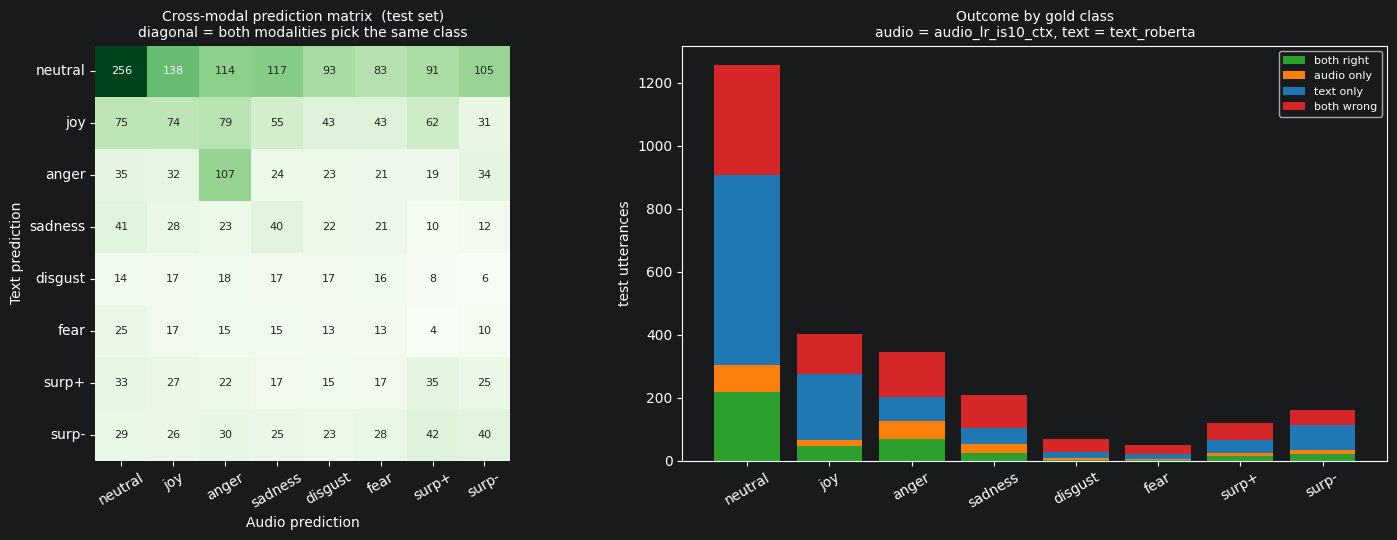


Per-class outcome (% of class support):
  emotion               both ok    audio     text  both wrong
  neutral                17.3%    7.0%   48.0%      27.7%
  joy                    11.2%    5.2%   52.0%      31.6%
  anger                  19.4%   16.8%   22.6%      41.2%
  sadness                11.1%   13.5%   25.0%      50.5%
  disgust                 4.4%    7.4%   29.4%      58.8%
  fear                    6.0%    4.0%   32.0%      58.0%
  surprise_positive      10.9%    9.2%   34.5%      45.4%
  surprise_negative      13.0%    8.0%   48.8%      30.2%


In [28]:
# How often do best audio-only and text-only agree, and who is right?

_audio_sf_x = np.load(get_prediction_path(_best_audio, 'test'))
_text_sf_x  = np.load(get_prediction_path('text_roberta', 'test'))
_audio_p    = _audio_sf_x.argmax(1)
_text_p     = _text_sf_x.argmax(1)
_y_test_x   = test_df['label_idx'].values.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Left: cross-modal confusion ──────────────────────────────────────────────
_cm_x = confusion_matrix(_text_p, _audio_p, labels=range(NUM_CLASSES))
sns.heatmap(_cm_x, annot=True, fmt='d', cmap='Greens', square=True,
            xticklabels=[COL_NAMES[c] for c in EMOTION_LABELS],
            yticklabels=[COL_NAMES[c] for c in EMOTION_LABELS],
            ax=axes[0], cbar=False, annot_kws={'size': 8})
axes[0].set_xlabel('Audio prediction'); axes[0].set_ylabel('Text prediction')
axes[0].set_title('Cross-modal prediction matrix  (test set)\n'
                  'diagonal = both modalities pick the same class', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)

_agree = (_audio_p == _text_p)
print(f'Audio vs Text full agreement: {_agree.mean():.2%}  '
      f'({_agree.sum()}/{len(_agree)} utterances)')
print(f'  both correct  : {((_audio_p == _y_test_x) & _agree).sum():>4d}')
print(f'  both wrong    : {((_audio_p != _y_test_x) & _agree).sum():>4d}')

# ── Right: per-emotion outcome stack ─────────────────────────────────────────
_outcomes = {k: np.zeros(NUM_CLASSES, int) for k in
             ('both_right', 'audio_only', 'text_only', 'both_wrong')}
for _c in range(NUM_CLASSES):
    _m  = _y_test_x == _c
    _ac = (_audio_p == _y_test_x) & _m
    _tc = (_text_p  == _y_test_x) & _m
    _outcomes['both_right'][_c] = (_ac &  _tc).sum()
    _outcomes['audio_only'][_c] = (_ac & ~_tc).sum()
    _outcomes['text_only' ][_c] = (~_ac & _tc).sum()
    _outcomes['both_wrong'][_c] = (~_ac & ~_tc & _m).sum()

_short  = [COL_NAMES[c] for c in EMOTION_LABELS]
_palette = {'both_right': '#2ca02c', 'audio_only': '#ff7f0e',
            'text_only':  '#1f77b4', 'both_wrong': '#d62728'}
_bottom = np.zeros(NUM_CLASSES)
for _k in ('both_right', 'audio_only', 'text_only', 'both_wrong'):
    axes[1].bar(_short, _outcomes[_k], bottom=_bottom,
                label=_k.replace('_', ' '), color=_palette[_k])
    _bottom = _bottom + _outcomes[_k]
axes[1].set_ylabel('test utterances')
axes[1].set_title(f'Outcome by gold class\n'
                  f'audio = {_best_audio}, text = text_roberta', fontsize=10)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_cross_modal_agreement.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPer-class outcome (% of class support):')
print(f'  {"emotion":<20s} {"both ok":>8s} {"audio":>8s} {"text":>8s} {"both wrong":>11s}')
for _c, lbl in enumerate(EMOTION_LABELS):
    _supp = (_y_test_x == _c).sum()
    if _supp == 0: continue
    print(f'  {lbl:<20s} '
          f'{_outcomes["both_right"][_c]/_supp:>7.1%} '
          f'{_outcomes["audio_only"][_c]/_supp:>7.1%} '
          f'{_outcomes["text_only"][_c]/_supp:>7.1%} '
          f'{_outcomes["both_wrong"][_c]/_supp:>10.1%}')


### 8.8 · Per-sample IG on the FusionMLP

The 8.3 ablation tells us *on average* how much each modality matters; this section runs Integrated Gradients on every test sample and splits the attribution between the **audio block** (first 8 dims = audio softmax) and the **text block** (the 768 CLS dims). For each utterance we can ask: did the network actually lean on the audio signal here, or did it just defer to the CLS embedding?

Baseline is the training-set mean; attributions are summed by modality block, then normalised to an *audio share* in [0, 1].


[WARN] Dropped 6 row(s) with NaN values from train_is10.parquet (train/is10).
Running IG (steps=32) on 2610 samples in batches of 256...


  0%|          | 0/11 [00:00<?, ?it/s]

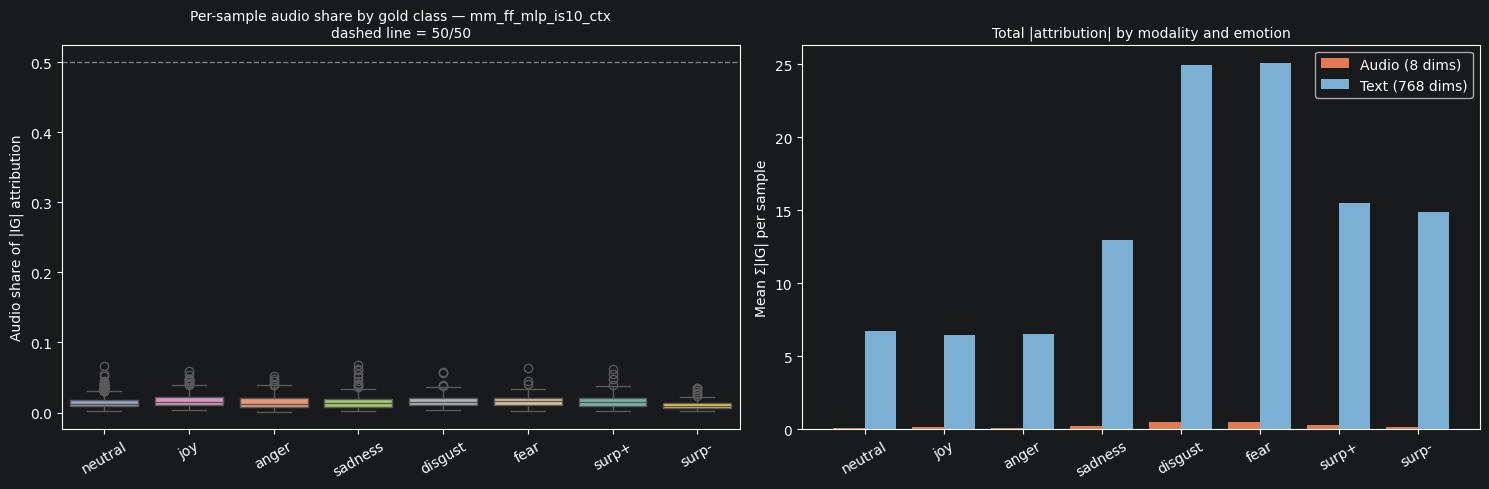


Audio carries > 50% of |attribution| in 0/2610 (0.0%) of test utterances.
Audio share quartiles: Q1=0.009  median=0.013  Q3=0.019

Fusion-MLP audio share averaged over late-fusion outcome groups:
  AUDIO HELPED cases (n=228):  mean audio share = 0.013
  AUDIO HURT   cases (n= 84):  mean audio share = 0.016


In [33]:
# Per-sample IG on the best feature-fusion MLP.
# Baseline = train mean; we sum |attribution| over the audio vs CLS dims.

if not _best_ff:
    print('No feature fusion model — run section 6.2 first.')
else:
    _audio_short  = _best_ff.replace('mm_ff_', '')
    _audio_for_ff = f'audio_{_audio_short}'

    _hp_ff   = json.loads(get_hparams_path(_best_ff).read_text())
    _ff_model = FusionMLP(INPUT_DIM, [_hp_ff['hidden_1'], _hp_ff['hidden_2']],
                          _hp_ff['dropout']).to(DEVICE)
    _ff_model.load_state_dict(torch.load(get_model_path(_best_ff), map_location=DEVICE))
    _ff_model.eval()

    _audio_train_sf = get_audio_softmax(_audio_for_ff, 'train', train_df)
    _audio_test_sf  = get_audio_softmax(_audio_for_ff, 'test',  test_df)

    X_train_ff = np.concatenate([_audio_train_sf, cls_train_sc], axis=1)
    X_test_ff  = np.concatenate([_audio_test_sf,  cls_test_sc],  axis=1)
    _baseline  = X_train_ff.mean(axis=0)

    IG_STEPS_FF = 32
    _IDX_AUDIO  = slice(0, AUDIO_DIM)
    _IDX_TEXT   = slice(AUDIO_DIM, INPUT_DIM)
    _y_test_v   = test_df['label_idx'].values.astype(int)

    def _ig_fusion(X, targets, steps=IG_STEPS_FF):
        x_in   = torch.tensor(X, dtype=torch.float32, device=DEVICE)
        x_base = torch.tensor(_baseline, dtype=torch.float32, device=DEVICE).expand_as(x_in)
        tgt    = torch.tensor(targets, dtype=torch.long, device=DEVICE)
        grads  = torch.zeros_like(x_in)
        for s in range(1, steps + 1):
            alpha  = s / steps
            interp = (x_base + alpha * (x_in - x_base)).detach().requires_grad_(True)
            sel    = _ff_model(interp).gather(1, tgt[:, None]).sum()
            grads  = grads + torch.autograd.grad(sel, interp)[0]
        return ((x_in - x_base) * grads / steps).detach().cpu().numpy()

    BATCH = 256
    attribs = np.zeros_like(X_test_ff, dtype=np.float32)
    print(f'Running IG (steps={IG_STEPS_FF}) on {len(X_test_ff)} samples in batches of {BATCH}...')
    for i in tqdm(range(0, len(X_test_ff), BATCH)):
        sl = slice(i, i + BATCH)
        attribs[sl] = _ig_fusion(X_test_ff[sl], _y_test_v[sl])

    audio_mag  = np.abs(attribs[:, _IDX_AUDIO]).sum(axis=1)
    text_mag   = np.abs(attribs[:, _IDX_TEXT]).sum(axis=1)
    total_mag  = audio_mag + text_mag
    audio_share = audio_mag / total_mag.clip(min=1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    _df_share = pd.DataFrame({
        'emotion':     [EMOTION_LABELS[c] for c in _y_test_v],
        'audio_share': audio_share,
    })
    sns.boxplot(data=_df_share, x='emotion', y='audio_share',
                order=EMOTION_LABELS, ax=axes[0],
                hue='emotion', palette='Set2', legend=False)
    axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
    axes[0].set_ylabel('Audio share of |IG| attribution')
    axes[0].set_xlabel('')
    axes[0].set_xticks(range(NUM_CLASSES))
    axes[0].set_xticklabels([COL_NAMES[c] for c in EMOTION_LABELS], rotation=30)
    axes[0].set_title(f'Per-sample audio share by gold class — {_best_ff}\n'
                      'dashed line = 50/50', fontsize=10)

    _per_class = np.zeros((NUM_CLASSES, 2))
    for _c in range(NUM_CLASSES):
        _m = _y_test_v == _c
        if _m.sum() == 0: continue
        _per_class[_c, 0] = audio_mag[_m].mean()
        _per_class[_c, 1] = text_mag[_m].mean()
    _x = np.arange(NUM_CLASSES); _w = 0.4
    axes[1].bar(_x - _w/2, _per_class[:, 0], _w, label='Audio (8 dims)',  color='#e07b54')
    axes[1].bar(_x + _w/2, _per_class[:, 1], _w, label='Text (768 dims)', color='#7bafd4')
    axes[1].set_xticks(_x)
    axes[1].set_xticklabels([COL_NAMES[c] for c in EMOTION_LABELS], rotation=30)
    axes[1].set_ylabel('Mean Σ|IG| per sample')
    axes[1].set_title('Total |attribution| by modality and emotion', fontsize=10)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_ig_fusion_modality.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nAudio carries > 50% of |attribution| in '
          f'{(audio_share > 0.5).sum()}/{len(audio_share)} '
          f'({(audio_share > 0.5).mean():.1%}) of test utterances.')
    print(f'Audio share quartiles: '
          f'Q1={np.percentile(audio_share, 25):.3f}  '
          f'median={np.median(audio_share):.3f}  '
          f'Q3={np.percentile(audio_share, 75):.3f}')

    # Help/hurt context (uses best late-fusion to define cases)
    if _best_late:
        _text_sf_h  = np.load(get_prediction_path('text_roberta', 'test'))
        _late_sf_h  = np.load(get_prediction_path(_best_late, 'test'))
        _text_p_h   = _text_sf_h.argmax(1)
        _late_p_h   = _late_sf_h.argmax(1)
        _helped = (_late_p_h == _y_test_v) & (_text_p_h != _y_test_v)
        _hurt   = (_late_p_h != _y_test_v) & (_text_p_h == _y_test_v)
        print('\nFusion-MLP audio share averaged over late-fusion outcome groups:')
        if _helped.any():
            print(f'  AUDIO HELPED cases (n={_helped.sum():>3d}):  '
                  f'mean audio share = {audio_share[_helped].mean():.3f}')
        if _hurt.any():
            print(f'  AUDIO HURT   cases (n={_hurt.sum():>3d}):  '
                  f'mean audio share = {audio_share[_hurt].mean():.3f}')

    del _ff_model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


### 8.9 · Confidence calibration per modality

For each modality, we look at the **softmax max** (the model's confidence in its top pick) split by whether that prediction was correct.  A well-behaved model should be more confident when it's right.  Per-class boxplots tell us *where* each modality is miscalibrated.


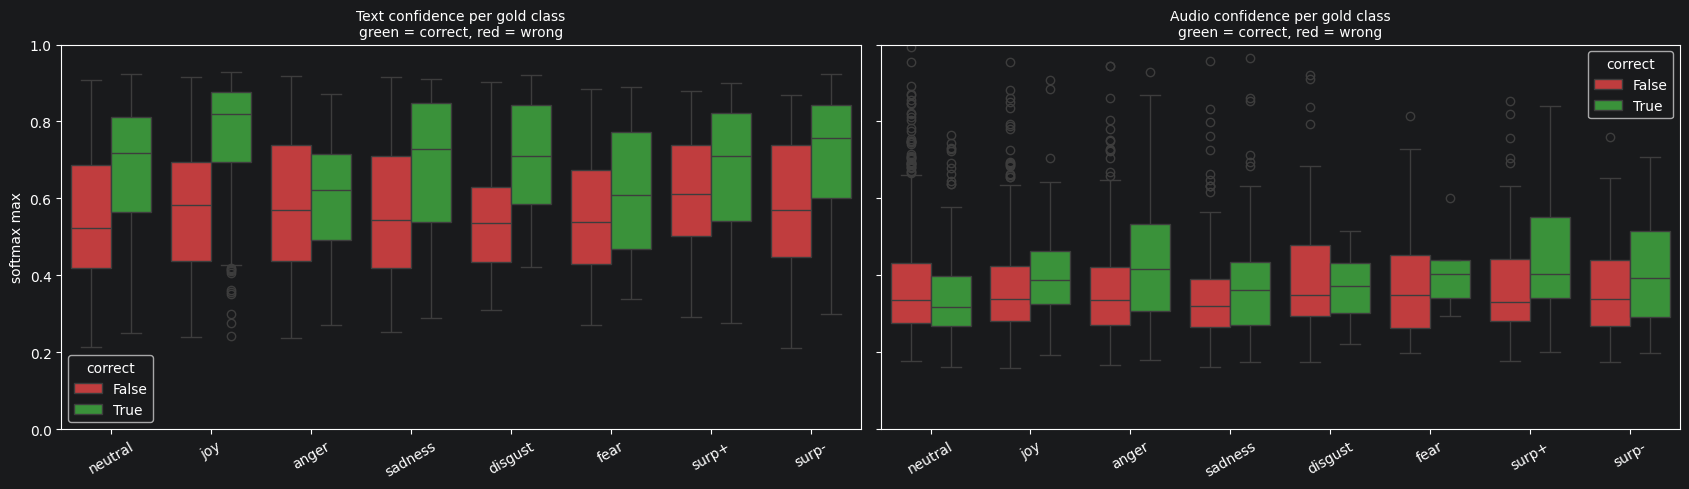

Mean softmax-max per modality (correct vs wrong):
  text    correct=0.688  wrong=0.567  gap=+0.121
  audio   correct=0.382  wrong=0.370  gap=+0.012

Per-class mean confidence gap (correct − wrong):
  class                 text gap  audio gap
  neutral                 +0.129     -0.027
  joy                     +0.184     +0.038
  anger                   +0.016     +0.067
  sadness                 +0.119     +0.049
  disgust                 +0.143     -0.035
  fear                    +0.060     +0.038
  surprise_positive       +0.070     +0.070
  surprise_negative       +0.134     +0.039


In [30]:
# Softmax-max distribution per modality, split by correct/incorrect, per gold class.

_text_sf_c  = np.load(get_prediction_path('text_roberta', 'test'))
_audio_sf_c = np.load(get_prediction_path(_best_audio, 'test'))
_y_test_c   = test_df['label_idx'].values.astype(int)

_records = []
for _mod, _sf in (('text', _text_sf_c), ('audio', _audio_sf_c)):
    _conf = _sf.max(axis=1)
    _pred = _sf.argmax(axis=1)
    for _i, (_c, _p, _v) in enumerate(zip(_y_test_c, _pred, _conf)):
        _records.append({
            'modality':     _mod,
            'true_emotion': EMOTION_LABELS[_c],
            'correct':      bool(_p == _c),
            'confidence':   float(_v),
        })
_df_conf = pd.DataFrame(_records)

fig, axes = plt.subplots(1, 2, figsize=(17, 5), sharey=True)
for _ax, _mod in zip(axes, ('text', 'audio')):
    _d = _df_conf[_df_conf['modality'] == _mod]
    sns.boxplot(data=_d, x='true_emotion', y='confidence',
                hue='correct', order=EMOTION_LABELS,
                palette={True: '#2ca02c', False: '#d62728'},
                ax=_ax)
    _ax.set_title(f'{_mod.capitalize()} confidence per gold class\n'
                  'green = correct, red = wrong', fontsize=10)
    _ax.set_xlabel(''); _ax.set_ylabel('softmax max')
    _ax.set_xticks(range(NUM_CLASSES))
    _ax.set_xticklabels([COL_NAMES[c] for c in EMOTION_LABELS], rotation=30)
    _ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_confidence_calibration.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Mean softmax-max per modality (correct vs wrong):')
for _mod in ('text', 'audio'):
    _ok = _df_conf[(_df_conf.modality == _mod) &  _df_conf.correct].confidence.mean()
    _wr = _df_conf[(_df_conf.modality == _mod) & ~_df_conf.correct].confidence.mean()
    _gap = _ok - _wr
    print(f'  {_mod:<6s}  correct={_ok:.3f}  wrong={_wr:.3f}  gap={_gap:+.3f}')

print('\nPer-class mean confidence gap (correct − wrong):')
print(f'  {"class":<20s} {"text gap":>9s} {"audio gap":>10s}')
for _lbl in EMOTION_LABELS:
    _row = _df_conf[_df_conf.true_emotion == _lbl]
    _tg  = (_row[(_row.modality=='text')  &  _row.correct].confidence.mean() -
            _row[(_row.modality=='text')  & ~_row.correct].confidence.mean())
    _ag  = (_row[(_row.modality=='audio') &  _row.correct].confidence.mean() -
            _row[(_row.modality=='audio') & ~_row.correct].confidence.mean())
    print(f'  {_lbl:<20s} {_tg:>+9.3f} {_ag:>+10.3f}')


### 8.10 · SHAP on the audio LR model (`LinearExplainer`)

SHAP values on a linear model are equivalent to *coefficient × (feature − mean)*, so they tell us how each feature in a *specific utterance* pushed the prediction.  This complements 8.1 (raw coefficients, constant across samples) and 8.5 (grouped magnitude) by adding sample-level distribution information.

- **Top panel**: beeswarm for two emotion classes — each dot is a test utterance,   position shows its SHAP value, colour shows the feature's value.
- **Bottom panel**: mean |SHAP| per emotion at the descriptor-group level, computed on   the test set — a cross-check on 8.5.


SHAP on audio_lr_is10  —  bg=(500, 1582), test=(2610, 1582)
SHAP values shape: (2610, 1582, 8)


/var/folders/sp/nlhn2z2x4nncrjcbf42ygfk40000gn/T/ipykernel_88182/3535817833.py:54: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


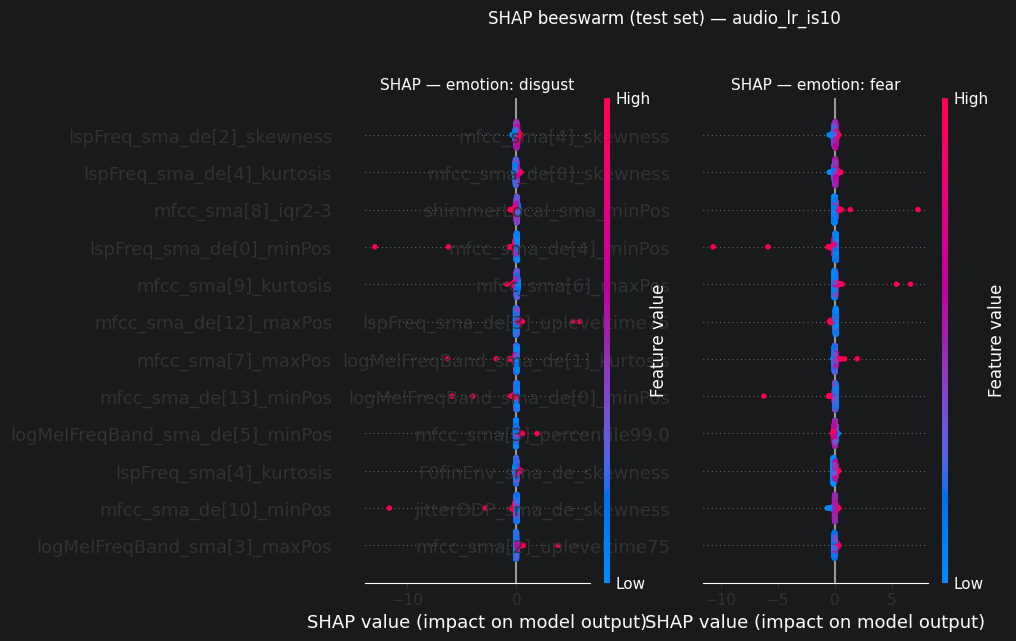

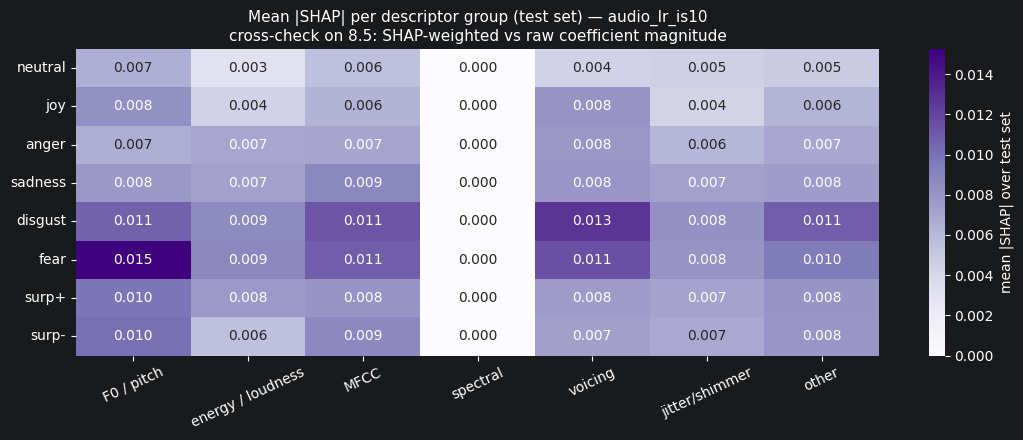

In [34]:
import shap

# Background and test samples (scaled features for the best LR audio model)
_lr_tag = _best_lr_tag
_lr_feature_set = _lr_tag.split('_')[-1]

with open(get_scaler_path(_lr_tag), 'rb') as f:
    _shap_scaler = pickle.load(f)

# Re-use the dataframes loaded earlier
_train_feat_df = pd.read_parquet(FEATURES_DIR / f'train_{_lr_feature_set}.parquet').dropna()
_test_feat_df  = pd.read_parquet(FEATURES_DIR / f'test_{_lr_feature_set}.parquet').dropna()
_align_test = test_df[['dialogue_id', 'utterance_id']].merge(
    _test_feat_df, on=['dialogue_id', 'utterance_id'], how='inner')

_feat_cols_shap = [c for c in _train_feat_df.columns
                   if c not in {'dialogue_id', 'utterance_id', 'label_idx'}]
_X_bg   = _shap_scaler.transform(_train_feat_df[_feat_cols_shap].sample(
                                    n=min(500, len(_train_feat_df)),
                                    random_state=RANDOM_SEED).values)
_X_test = _shap_scaler.transform(_align_test[_feat_cols_shap].values)
_y_test_shap = _align_test['label_idx'].values.astype(int)

print(f'SHAP on {_lr_tag}  —  bg={_X_bg.shape}, test={_X_test.shape}')
_explainer  = shap.LinearExplainer(_lr_clf, _X_bg)
_shap_vals  = _explainer.shap_values(_X_test)        # (N, F, C)
print(f'SHAP values shape: {_shap_vals.shape}')

# === Beeswarm for two focal emotions ============================================
# Pick the most informative classes (highest dynamic range of SHAP)
_class_range = np.array([np.abs(_shap_vals[:, :, c]).mean()
                         for c in range(NUM_CLASSES)])
_focal = np.argsort(_class_range)[-2:][::-1]   # top 2 by mean |SHAP|

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for _ax, _c in zip(axes, _focal):
    _sv = _shap_vals[:, :, _c]
    # Top-K features by mean |SHAP|
    _topk = 12
    _imp  = np.abs(_sv).mean(axis=0)
    _top_idx = np.argsort(_imp)[-_topk:][::-1]
    _expl = shap.Explanation(
        values        = _sv[:, _top_idx],
        base_values   = _explainer.expected_value[_c]
                          if hasattr(_explainer.expected_value, '__len__')
                          else _explainer.expected_value,
        data          = _X_test[:, _top_idx],
        feature_names = [_feat_cols_shap[i] for i in _top_idx],
    )
    plt.sca(_ax)
    shap.plots.beeswarm(_expl, show=False, max_display=_topk)
    _ax.set_title(f'SHAP — emotion: {EMOTION_LABELS[_c]}', fontsize=11)
plt.suptitle(f'SHAP beeswarm (test set) — {_lr_tag}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_shap_audio_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()

# === Group-level mean |SHAP| heatmap ============================================
# Reuse _audio_group from 8.5
_feat_groups_shap = np.array([_audio_group(c) for c in _feat_cols_shap])
_shap_imp_by_group = np.zeros((NUM_CLASSES, len(_groups)))
for _c in range(NUM_CLASSES):
    _abs = np.abs(_shap_vals[:, :, _c]).mean(axis=0)
    for _gi, _g in enumerate(_groups):
        _m = _feat_groups_shap == _g
        if _m.sum() == 0: continue
        _shap_imp_by_group[_c, _gi] = _abs[_m].mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(_shap_imp_by_group, annot=True, fmt='.3f', cmap='Purples',
            xticklabels=_groups,
            yticklabels=[COL_NAMES[c] for c in EMOTION_LABELS],
            ax=ax, cbar_kws={'label': 'mean |SHAP| over test set'})
ax.set_title(f'Mean |SHAP| per descriptor group (test set) — {_lr_tag}\n'
             f'cross-check on 8.5: SHAP-weighted vs raw coefficient magnitude',
             fontsize=11)
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_shap_audio_groups.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 8.11 · LIME on the RoBERTa text classifier

LIME perturbs the input by randomly **removing words** and fits a sparse linear surrogate on the local neighbourhood.  This gives a complementary, model-agnostic view of which words matter — a cross-check on the IG attributions from 8.6.

We pick one high-confidence correct example per emotion (same selection rule as 8.6) and visualise LIME's per-token weights for the true class.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running LIME on 8 examples (250 perturbations each, 10 top features)...


  0%|          | 0/8 [00:00<?, ?it/s]

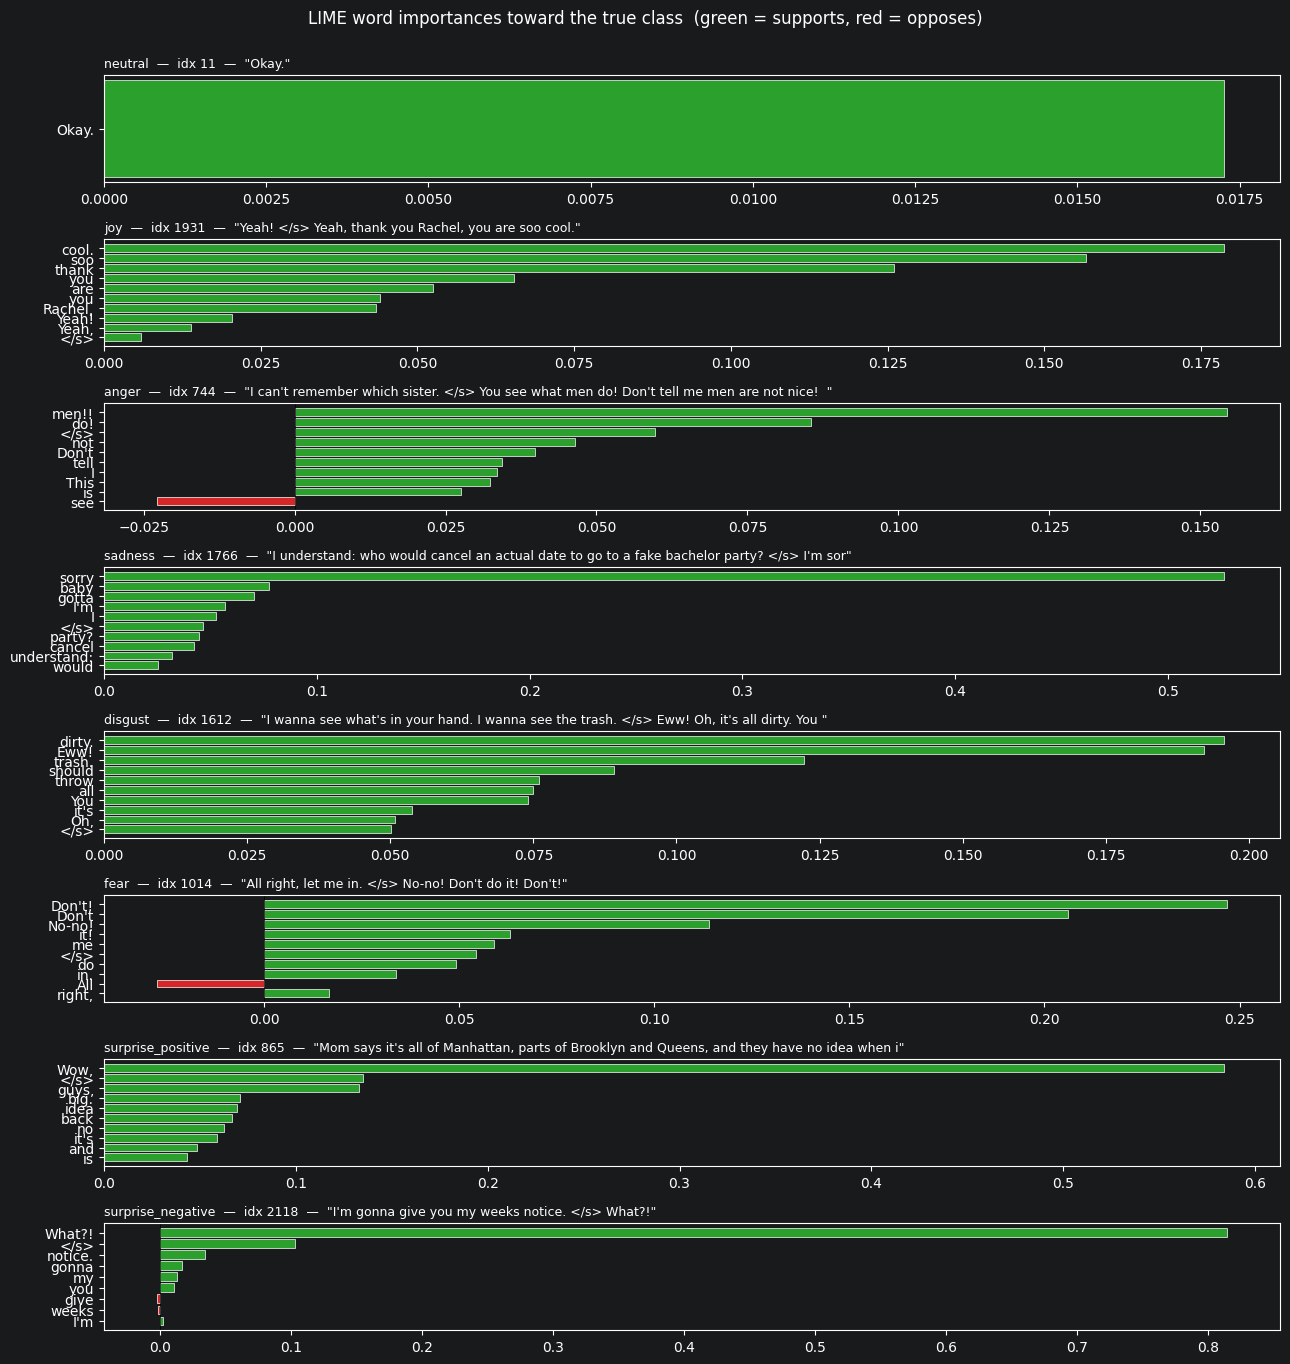

In [35]:
from lime.lime_text import LimeTextExplainer

LIME_NUM_FEATURES = 10
LIME_NUM_SAMPLES  = 250    # neighbourhood size; trade-off speed vs stability

_lime_tok   = RobertaTokenizer.from_pretrained(ROBERTA_SOURCE)
_lime_model = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_SOURCE, num_labels=NUM_CLASSES
).to(DEVICE).eval()


def _roberta_predict_proba(texts):
    """List[str] -> (N, NUM_CLASSES) softmax probabilities."""
    out = []
    for i in range(0, len(texts), 32):
        batch = list(texts[i : i + 32])
        enc = _lime_tok(batch, padding=True, truncation=True,
                        max_length=128, return_tensors='pt')
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            logits = _lime_model(**enc).logits
        out.append(F.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(out).astype(np.float64)


# Same selection rule as 8.6: top-confidence correct test predictions, one per emotion
_text_sf_lime = np.load(get_prediction_path('text_roberta', 'test'))
_text_pred_lime = _text_sf_lime.argmax(1)
_y_test_lime = test_df['label_idx'].values.astype(int)
_lime_examples = {}
for _c in range(NUM_CLASSES):
    _mask = (_text_pred_lime == _y_test_lime) & (_y_test_lime == _c)
    if _mask.sum() == 0:
        continue
    _pool = np.where(_mask)[0]
    _conf = _text_sf_lime[_pool, _c]
    _lime_examples[_c] = int(_pool[np.argmax(_conf)])

_lime_explainer = LimeTextExplainer(
    class_names = EMOTION_LABELS,
    bow         = False,         # don't collapse identical words
    split_expression = r'\s+',  # whitespace-tokenise
)

_lime_results = []
print(f'Running LIME on {len(_lime_examples)} examples '
      f'({LIME_NUM_SAMPLES} perturbations each, {LIME_NUM_FEATURES} top features)...')
_texts_lime = test_df['text_with_context'].values
for _c, _i in tqdm(_lime_examples.items(), total=len(_lime_examples)):
    _txt = str(_texts_lime[_i])
    _exp = _lime_explainer.explain_instance(
        _txt, _roberta_predict_proba,
        num_features = LIME_NUM_FEATURES,
        num_samples  = LIME_NUM_SAMPLES,
        labels       = [_c],
    )
    _lime_results.append({'emotion': EMOTION_LABELS[_c], 'idx': _i,
                          'text': _txt, 'exp': _exp.as_list(label=_c)})

del _lime_model
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()

# Plot
_n = len(_lime_results)
fig, axes = plt.subplots(_n, 1, figsize=(13, 1.7 * _n))
if _n == 1: axes = [axes]
for _ax, _r in zip(axes, _lime_results):
    if not _r['exp']:
        _ax.set_title(f'{_r["emotion"]}  (no LIME features)', fontsize=10)
        _ax.axis('off'); continue
    _words, _weights = zip(*_r['exp'])
    _colors = ['#2ca02c' if w > 0 else '#d62728' for w in _weights]
    _y = np.arange(len(_words))
    _ax.barh(_y, _weights, color=_colors, edgecolor='white', linewidth=0.5)
    _ax.set_yticks(_y); _ax.set_yticklabels(_words)
    _ax.invert_yaxis()
    _ax.axvline(0, color='black', linewidth=0.5)
    _snip = _r['text'][:90].replace('\n', ' ')
    _ax.set_title(f'{_r["emotion"]}  —  idx {_r["idx"]}  —  "{_snip}"', fontsize=9, loc='left')
plt.suptitle(f'LIME word importances toward the true class  '
             f'(green = supports, red = opposes)', fontsize=12, y=1.0)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_lime_text.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 8.12 · SHAP on the FusionMLP (`GradientExplainer`)

`GradientExplainer` approximates SHAP using expected-gradient sampling over a background set — methodologically different from IG (which uses a single straight-line path).  We aggregate |SHAP| over the audio block (8 dims) vs the CLS block (768 dims) per emotion and overlay it on the IG numbers from 8.8 to see whether the two attribution methods agree.


[WARN] Dropped 6 row(s) with NaN values from train_is10.parquet (train/is10).
GradientExplainer  bg=200, test sample=400...
SHAP shape: (400, 776, 8)


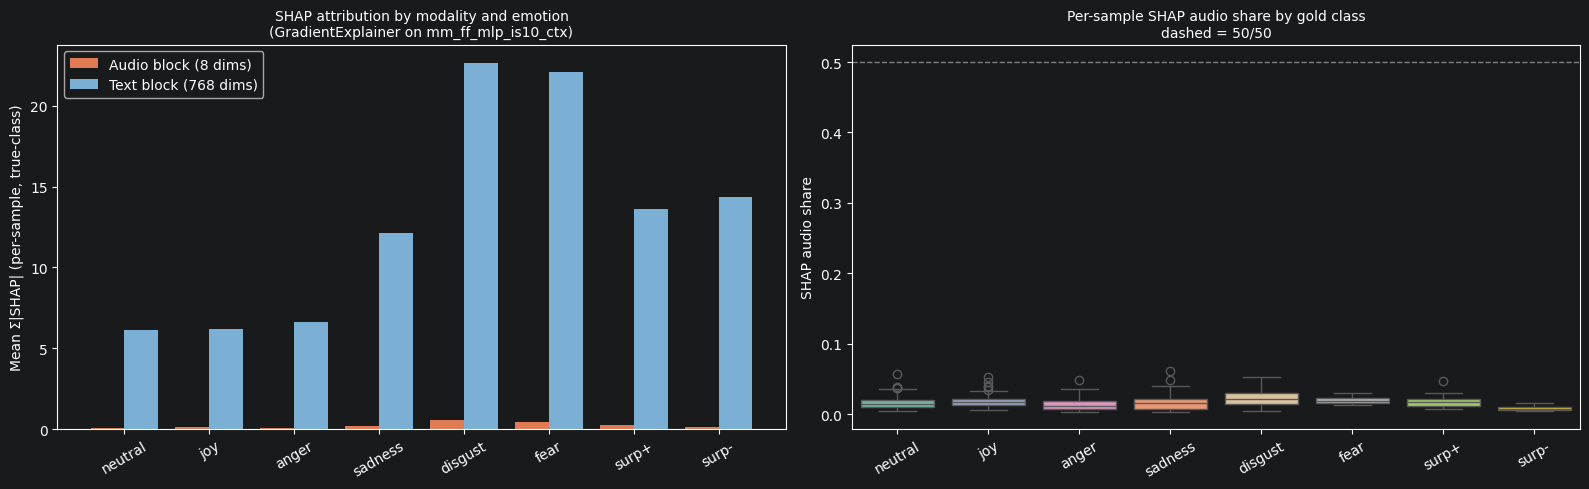


Mean SHAP audio share (whole test subsample): 0.016
Median SHAP audio share                     : 0.015
Audio carries > 50% of SHAP in              : 0/400 (0.0%)


In [36]:
import shap

if not _best_ff:
    print('No feature fusion model — run section 6.2 first.')
else:
    _audio_short = _best_ff.replace('mm_ff_', '')
    _audio_for_ff = f'audio_{_audio_short}'

    _hp_shap  = json.loads(get_hparams_path(_best_ff).read_text())
    _ff_shap  = FusionMLP(INPUT_DIM, [_hp_shap['hidden_1'], _hp_shap['hidden_2']],
                          _hp_shap['dropout']).to(DEVICE)
    _ff_shap.load_state_dict(torch.load(get_model_path(_best_ff), map_location=DEVICE))
    _ff_shap.eval()

    _audio_train_sf2 = get_audio_softmax(_audio_for_ff, 'train', train_df)
    _audio_test_sf2  = get_audio_softmax(_audio_for_ff, 'test',  test_df)
    _X_train_ff = np.concatenate([_audio_train_sf2, cls_train_sc], axis=1).astype(np.float32)
    _X_test_ff  = np.concatenate([_audio_test_sf2,  cls_test_sc],  axis=1).astype(np.float32)
    _y_test_v2  = test_df['label_idx'].values.astype(int)

    # Background = stratified sample of train (small to keep SHAP fast)
    SHAP_BG_SIZE   = 200
    SHAP_TEST_SIZE = 400         # subsample test for tractability
    _rng = np.random.default_rng(RANDOM_SEED)
    _bg_idx   = _rng.choice(len(_X_train_ff), SHAP_BG_SIZE,   replace=False)
    _te_idx   = _rng.choice(len(_X_test_ff),  SHAP_TEST_SIZE, replace=False)

    _bg_tensor = torch.tensor(_X_train_ff[_bg_idx], device=DEVICE)
    _te_tensor = torch.tensor(_X_test_ff[_te_idx],  device=DEVICE)

    print(f'GradientExplainer  bg={SHAP_BG_SIZE}, test sample={SHAP_TEST_SIZE}...')
    _g_expl = shap.GradientExplainer(_ff_shap, _bg_tensor)
    _shap_ff = _g_expl.shap_values(_te_tensor, nsamples=50)
    print(f'SHAP shape: {_shap_ff.shape}')   # (N, INPUT_DIM, NUM_CLASSES)

    # ── Aggregate by modality block per emotion ─────────────────────────────
    _shap_audio = np.abs(_shap_ff[:, :AUDIO_DIM, :]).sum(axis=1)        # (N, C)
    _shap_text  = np.abs(_shap_ff[:, AUDIO_DIM:, :]).sum(axis=1)        # (N, C)
    _y_subset   = _y_test_v2[_te_idx]

    # Mean over samples whose TRUE label == c, looking at SHAP for that class c
    _shap_per_class = np.zeros((NUM_CLASSES, 2))
    for _c in range(NUM_CLASSES):
        _m = _y_subset == _c
        if _m.sum() == 0: continue
        _shap_per_class[_c, 0] = _shap_audio[_m, _c].mean()
        _shap_per_class[_c, 1] = _shap_text[_m, _c].mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    _x_c = np.arange(NUM_CLASSES); _wb = 0.4
    axes[0].bar(_x_c - _wb/2, _shap_per_class[:, 0], _wb,
                label='Audio block (8 dims)', color='#e07b54')
    axes[0].bar(_x_c + _wb/2, _shap_per_class[:, 1], _wb,
                label='Text block (768 dims)', color='#7bafd4')
    axes[0].set_xticks(_x_c)
    axes[0].set_xticklabels([COL_NAMES[c] for c in EMOTION_LABELS], rotation=30)
    axes[0].set_ylabel('Mean Σ|SHAP| (per-sample, true-class)')
    axes[0].set_title(f'SHAP attribution by modality and emotion\n'
                      f'(GradientExplainer on {_best_ff})', fontsize=10)
    axes[0].legend()

    # Audio share boxplot per class
    _audio_total = _shap_audio[np.arange(SHAP_TEST_SIZE), _y_subset]
    _text_total  = _shap_text [np.arange(SHAP_TEST_SIZE), _y_subset]
    _share = _audio_total / (_audio_total + _text_total).clip(min=1e-9)
    _df_share_shap = pd.DataFrame({
        'emotion':     [EMOTION_LABELS[c] for c in _y_subset],
        'audio_share': _share,
    })
    sns.boxplot(data=_df_share_shap, x='emotion', y='audio_share',
                order=EMOTION_LABELS, ax=axes[1],
                hue='emotion', palette='Set2', legend=False)
    axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
    axes[1].set_ylabel('SHAP audio share')
    axes[1].set_xlabel('')
    axes[1].set_xticks(range(NUM_CLASSES))
    axes[1].set_xticklabels([COL_NAMES[c] for c in EMOTION_LABELS], rotation=30)
    axes[1].set_title('Per-sample SHAP audio share by gold class\n'
                      'dashed = 50/50', fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_shap_fusion.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nMean SHAP audio share (whole test subsample): {_share.mean():.3f}')
    print(f'Median SHAP audio share                     : {np.median(_share):.3f}')
    print(f'Audio carries > 50% of SHAP in              : {(_share > 0.5).sum()}/{len(_share)} '
          f'({(_share > 0.5).mean():.1%})')

    del _ff_shap
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


### 8.13 · LIME on the FusionMLP (`LimeTabularExplainer`)

LIME on the FusionMLP fits a sparse linear surrogate around each utterance by perturbing the audio+CLS feature vector and observing the model's response.  We explain a small set of **interesting cases** — specifically the help/hurt examples from 8.4 — and aggregate the per-feature weights by modality block to see whether LIME's local surrogate agrees with IG (8.8) and SHAP (8.12) on which modality drove each prediction.


[WARN] Dropped 6 row(s) with NaN values from train_is10.parquet (train/is10).
LIME explaining 3 HELP and 3 HURT samples (800 perturbations each)...


LIME:   0%|          | 0/6 [00:00<?, ?it/s]


LIME — per-sample modality summary (weights toward the TRUE class):
 idx  group true_emotion  audio_lime  text_lime  n_audio_in_top  audio_share
1820 helped      neutral    0.000000  -0.005597               0     0.000000
 259 helped      neutral    0.000000  -0.016589               0     0.000000
2134 helped      neutral    0.000000  -0.018552               0     0.000000
 258   hurt      sadness    0.000000   0.057652               0     0.000000
1909   hurt        anger    0.000000  -0.004903               0     0.000000
2260   hurt        anger    0.001523   0.032108               1     0.045284

(num_features=50; if n_audio_in_top is 0, the audio block had no feature large enough to make LIME's sparse surrogate.)


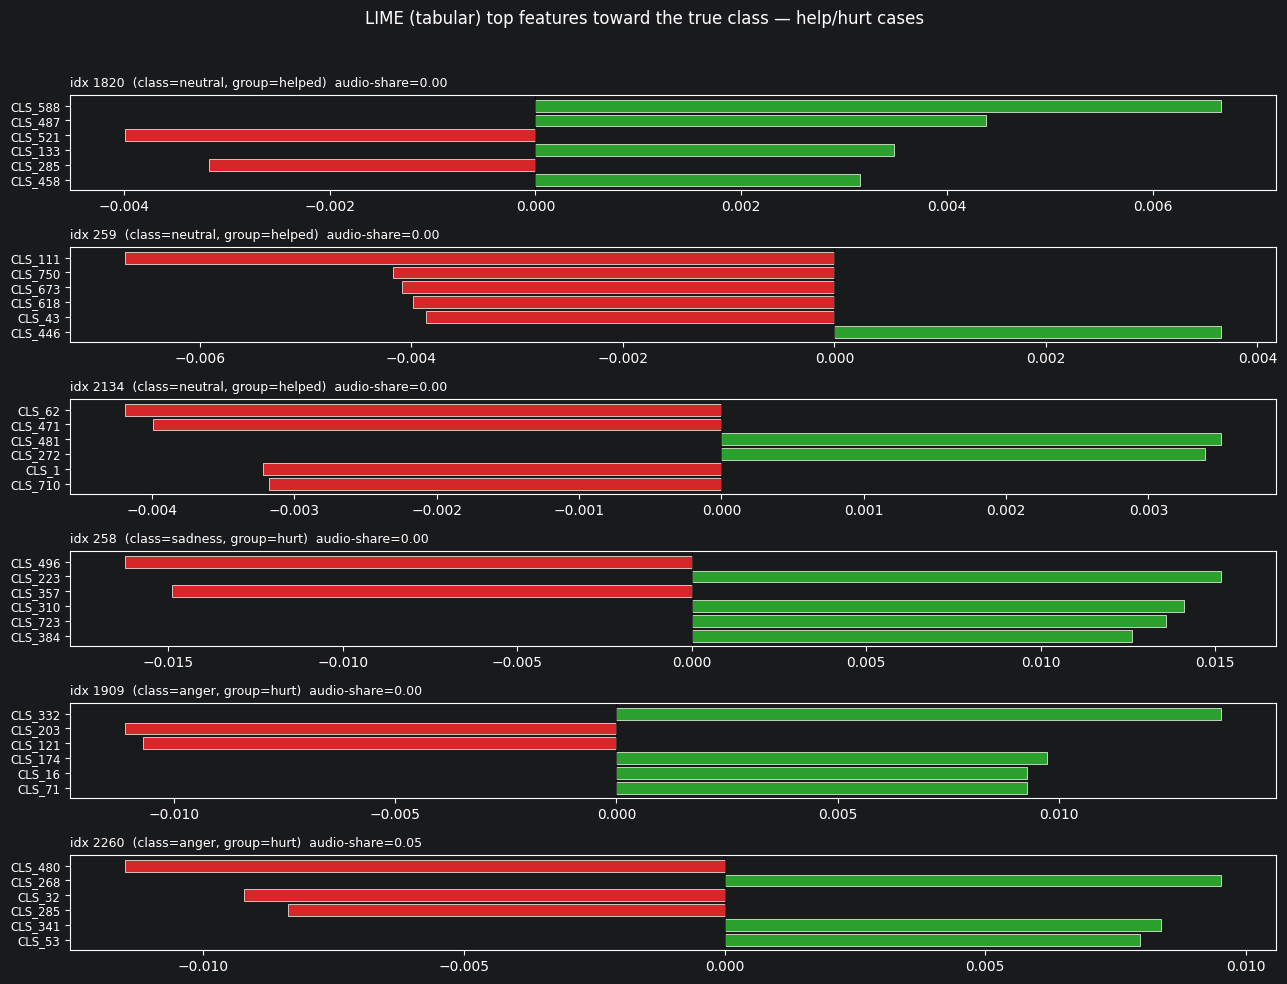


Mean LIME audio-share by outcome group:
         mean  count
group               
helped  0.000      3
hurt    0.015      3


In [37]:
from lime.lime_tabular import LimeTabularExplainer

LIME_TAB_N_HELP = 3   # cases to explain from "audio helped"
LIME_TAB_N_HURT = 3   # cases from "audio hurt"
LIME_TAB_SAMPLES = 800
LIME_TAB_FEATURES = 50    # large enough that audio dims have a chance to surface

if not _best_ff or not _best_late:
    print('Need both best_ff and best_late — run sections 5+6 first.')
else:
    _audio_short = _best_ff.replace('mm_ff_', '')
    _audio_for_ff = f'audio_{_audio_short}'
    _hp_l = json.loads(get_hparams_path(_best_ff).read_text())
    _ff_lime = FusionMLP(INPUT_DIM, [_hp_l['hidden_1'], _hp_l['hidden_2']],
                         _hp_l['dropout']).to(DEVICE)
    _ff_lime.load_state_dict(torch.load(get_model_path(_best_ff), map_location=DEVICE))
    _ff_lime.eval()

    _audio_train_sf3 = get_audio_softmax(_audio_for_ff, 'train', train_df)
    _audio_test_sf3  = get_audio_softmax(_audio_for_ff, 'test',  test_df)
    _X_train_l = np.concatenate([_audio_train_sf3, cls_train_sc], axis=1).astype(np.float32)
    _X_test_l  = np.concatenate([_audio_test_sf3,  cls_test_sc],  axis=1).astype(np.float32)

    _feat_names = ([f'audio_p({EMOTION_LABELS[i]})' for i in range(NUM_CLASSES)]
                   + [f'CLS_{i}' for i in range(TEXT_DIM)])

    def _ff_predict_proba(X):
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32, device=DEVICE)
            return F.softmax(_ff_lime(t), dim=1).cpu().numpy()

    _tab_explainer = LimeTabularExplainer(
        training_data = _X_train_l,
        feature_names = _feat_names,
        class_names   = EMOTION_LABELS,
        mode          = 'classification',
        discretize_continuous = False,
        random_state  = RANDOM_SEED,
    )

    # Identify help/hurt cases via late-fusion outcomes (same as 8.4)
    _text_sf_t = np.load(get_prediction_path('text_roberta', 'test'))
    _late_sf_t = np.load(get_prediction_path(_best_late, 'test'))
    _y_test_t  = test_df['label_idx'].values.astype(int)
    _help_mask = (_late_sf_t.argmax(1) == _y_test_t) & (_text_sf_t.argmax(1) != _y_test_t)
    _hurt_mask = (_late_sf_t.argmax(1) != _y_test_t) & (_text_sf_t.argmax(1) == _y_test_t)

    _rng = np.random.default_rng(RANDOM_SEED)
    _help_idxs = _rng.choice(np.where(_help_mask)[0],
                              min(LIME_TAB_N_HELP, _help_mask.sum()), replace=False)
    _hurt_idxs = _rng.choice(np.where(_hurt_mask)[0],
                              min(LIME_TAB_N_HURT, _hurt_mask.sum()), replace=False)
    print(f'LIME explaining {len(_help_idxs)} HELP and {len(_hurt_idxs)} HURT samples '
          f'({LIME_TAB_SAMPLES} perturbations each)...')

    _records = []
    for _idx in tqdm(np.concatenate([_help_idxs, _hurt_idxs]), desc='LIME'):
        _idx = int(_idx)
        _true = int(_y_test_t[_idx])
        _exp = _tab_explainer.explain_instance(
            data_row     = _X_test_l[_idx],
            predict_fn   = _ff_predict_proba,
            labels       = [_true],
            num_features = LIME_TAB_FEATURES,
            num_samples  = LIME_TAB_SAMPLES,
        )
        _pairs = _exp.as_list(label=_true)   # [(feature_name, weight), ...]
        # Aggregate by block
        _audio_w = sum(w for n, w in _pairs if n.startswith('audio_p'))
        _text_w  = sum(w for n, w in _pairs if n.startswith('CLS_'))
        _n_audio = sum(1 for n, _ in _pairs if n.startswith('audio_p'))
        _records.append({
            'idx': _idx,
            'group': 'helped' if _idx in _help_idxs else 'hurt',
            'true_emotion': EMOTION_LABELS[_true],
            'audio_lime':   _audio_w,
            'text_lime':    _text_w,
            'n_audio_in_top': _n_audio,
            'audio_share':  abs(_audio_w) / max(abs(_audio_w) + abs(_text_w), 1e-9),
            'top_features': _pairs[:6],
        })

    _df_lime = pd.DataFrame(_records)
    print('\nLIME — per-sample modality summary (weights toward the TRUE class):')
    print(_df_lime[['idx', 'group', 'true_emotion',
                    'audio_lime', 'text_lime', 'n_audio_in_top', 'audio_share']].to_string(index=False))
    print(f'\n(num_features={LIME_TAB_FEATURES}; if n_audio_in_top is 0, the audio block had no '
          f'feature large enough to make LIME\'s sparse surrogate.)')

    # ── Plot: top features per sample ──────────────────────────────────────
    _n = len(_records)
    fig, axes = plt.subplots(_n, 1, figsize=(13, 1.6 * _n))
    if _n == 1: axes = [axes]
    for _ax, _r in zip(axes, _records):
        names, weights = zip(*_r['top_features'])
        _colors = ['#2ca02c' if w > 0 else '#d62728' for w in weights]
        _y = np.arange(len(names))
        _ax.barh(_y, weights, color=_colors, edgecolor='white', linewidth=0.5)
        _ax.set_yticks(_y); _ax.set_yticklabels(names, fontsize=8.5)
        _ax.invert_yaxis()
        _ax.axvline(0, color='black', linewidth=0.5)
        _ax.set_title(f'idx {_r["idx"]}  '
                      f'(class={_r["true_emotion"]}, group={_r["group"]})  '
                      f'audio-share={_r["audio_share"]:.2f}',
                      fontsize=9, loc='left')
    plt.suptitle('LIME (tabular) top features toward the true class — help/hurt cases',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'plots' / 'xai_lime_fusion.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary of modality contribution by group ──────────────────────────
    print('\nMean LIME audio-share by outcome group:')
    print(_df_lime.groupby('group')['audio_share'].agg(['mean', 'count']).round(3))

    del _ff_lime
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
